# Ploting Paper Figures

<span style="color:red">This code was last tested on February 25, 2026, and is running without issues.  
It's still a draft. Not ready to share on github yet</span>


**PURPOSE:** Code to handle the obtained data carefully (without affecting the notebooks that generate the results) and to experiment with different color palettes and graphical layouts for the paper's figures.

__________________________________________________________________________________________  

**Input files:**  

 
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_dir/processed_data/" 
  

 
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/image_data/" 


**Output files:** 

 
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_dir/processed_data/"  


 
on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_dir/processed_image/

__________________________________________________________________________________________

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import cmocean
import os

#### **Variables on each pickle file:**

 

matrix_alltogether.pkl = [idx, dist_i, zi, sal_i, temp_i, rho_i, e1_i, e2_i, u_i, v_i, rea_i]  
matrix_calc_alltogether.pkl = [distância, profundidade_média, N², S², Ri, e_médio, Az]  
Rotated_velocicty.pkl = [x, z, vr, ur]    
bathymetry.pkl = [dist, depth_drift]  
junta_pic_Fr.pkl= [dist_pic_Fr, z_Fr, pic, Fr] 


In [3]:
input_data = '../output_dir/processed_data/'
output_image = '../output_dir/processed_image/'
#path = "/Users/deboragadelha/Jupyter/campo_18julho2022_paper/processed_data/"

#os.makedirs(input_data, exist_ok=True)


In [4]:
#==============================================
# opening variables from notebook STEP3_DRIFT:
#==============================================


with open(input_data + 'matrix_alltogether.pkl', 'rb') as io:
    mtz_tj = pickle.load(io)

with open(input_data + 'matrix_calc_alltogether.pkl', 'rb') as io:
    mtz_tj_calc = pickle.load(io)

with open(input_data + 'Rotated_velocity.pkl', 'rb') as io:
    m_corr = pickle.load(io)

with open(input_data + 'bathymetry.pkl', 'rb') as io:
    bat = pickle.load(io)    

#====================================================
# identifying variables from notebook STEP3_DRIFT:
#====================================================

idx = mtz_tj[:,0]
x = mtz_tj[:,1]
z = mtz_tj[:,2]
sal = mtz_tj[:,3]
temp = mtz_tj[:,4]
rho = mtz_tj[:,5]
e1_i = mtz_tj[:,6] #teste
e2_i = mtz_tj[:,7] #teste
x_calc = mtz_tj_calc[:,0]
z_calc = mtz_tj_calc[:,1]
N2 = mtz_tj_calc[:,2]
S2 = mtz_tj_calc[:,3]
Ri = mtz_tj_calc[:,4]
Epsilon = mtz_tj_calc[:,5]
Az = mtz_tj_calc[:,6]
corr_x = m_corr[0]
corr_z = m_corr[1]
corr_long = m_corr[2]
corr_across = m_corr[3]
dist_batimetria = bat[0]
depth_batimetria = bat[1]

In [5]:
len (dist_batimetria)

107

In [6]:
#================================================
# opening variables from notebook Calcula Froud:
#================================================

with open(input_data + 'junta_pic_Fr.pkl', 'rb') as io:
    mtz_pic_Fr = pickle.load(io)


#======================================================
# identifying variables from notebook Calc_Froud:
#======================================================

dist_pic_Fr = mtz_pic_Fr[0]
z_Fr = mtz_pic_Fr[1]
pic = mtz_pic_Fr[2]
Fr = mtz_pic_Fr[3]

## Ploting the variables with the calculated pycnocline: 

In [7]:
def plot_sets(ax):
    #ax.plot(x, -depth_drift, 'k')
    ax.plot(dist_batimetria, -depth_batimetria, 'k')
    ax.axvline(dist_batimetria[62], color='k', ls=':', lw=2)
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Depth (m)')

In [23]:
#======= Beauty kit for the plottings ======:
#Choosing every detail to make the most pretty diagram ---

# Config to depth layout (Y axis)
y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)


# Defining fontsize: 
fontsize_main = 14
fontsize_title = 16 # bigger for the title
fontsize_ticks = 12 # smaller if you want for the axis numbers (ticks)
#===========================================

## **Salinity, Temperature and Density:**



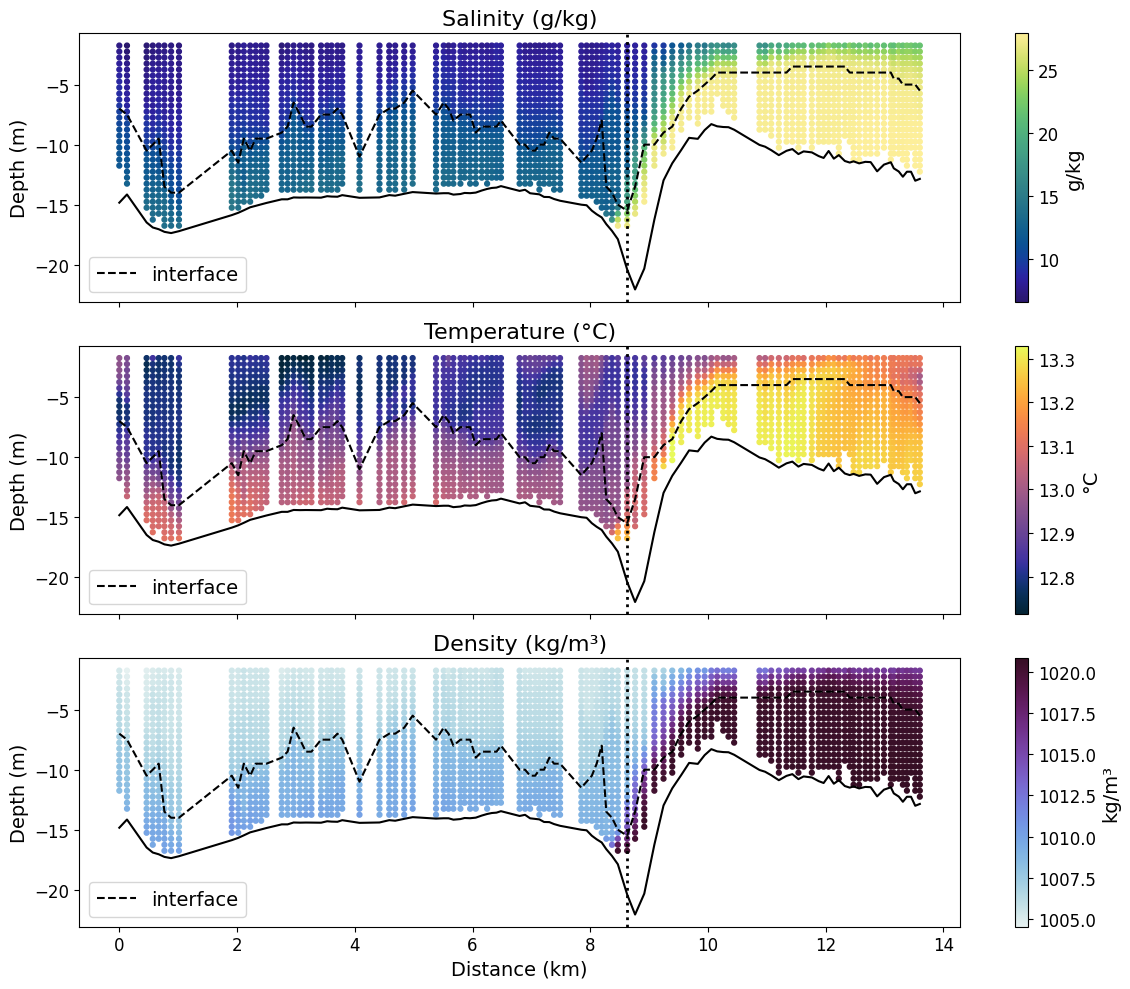

In [16]:
# --- CODE TO PLOTS VARIABLES AND ADD THE PYCNOCLINE ---
#Depht configuration and fontsize defined on previous cells (Y axis):

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# === SALINITY ===
cb = axs[0].scatter(x, -z, s=12, c=sal, cmap=cmocean.cm.haline)
axs[0].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # Adicionando os pontos aqui
plot_sets(axs[0])
axs[0].set_title('Salinity (g/kg)', fontsize=fontsize_title)
#axs[0].set_ylabel('Depth (m)')
axs[0].legend(fontsize=fontsize_main)
#fig.colorbar(cb, ax=axs[0], label='g/kg')

cbar = fig.colorbar(cb, ax=axs[0])
cbar.set_label('g/kg', fontsize=fontsize_main) # Label da Colorbar
cbar.ax.tick_params(labelsize=fontsize_ticks) # Números da Colorbar


# === TEMPERATURE ===
cb = axs[1].scatter(x, -z, s=12, c=temp, cmap=cmocean.cm.thermal)
axs[1].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # Adicionando os pontos aqui
plot_sets(axs[1])
axs[1].set_title('Temperature (°C)', fontsize=fontsize_title)
#axs[1].set_ylabel('Depth (m)')
axs[1].legend(fontsize=fontsize_main)
#fig.colorbar(cb, ax=axs[1], label='°C')

cbar = fig.colorbar(cb, ax=axs[1])
cbar.set_label('°C', fontsize=fontsize_main) # Label da Colorbar
cbar.ax.tick_params(labelsize=fontsize_ticks) # Números da Colorbar


# === DENSITY ===
cb = axs[2].scatter(x, -z, s=12, c=rho, cmap=cmocean.cm.dense)
axs[2].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # Adicionando os pontos aqui
plot_sets(axs[2])
axs[2].set_title('Density (kg/m³)', fontsize=fontsize_title)
#axs[2].set_ylabel('Depth (m)')
#axs[2].set_xlabel('Distance (km)')
axs[2].legend(fontsize=fontsize_main)
#fig.colorbar(cb, ax=axs[2], label='kg/m³')
cbar = fig.colorbar(cb, ax=axs[2])
cbar.set_label('kg/m³', fontsize=fontsize_main) # Label da Colorbar
cbar.ax.tick_params(labelsize=fontsize_ticks) # Números da Colorbar

# Remove numbers from X axis in the first 2 plots:  
axs[0].tick_params(labelbottom=False)
axs[0].set_xlabel('')
axs[1].tick_params(labelbottom=False)
axs[1].set_xlabel('')

# Axis labels:
axs[2].set_xlabel('Distance (km)', fontsize=fontsize_main)
axs[0].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[1].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[2].set_ylabel('Depth (m)', fontsize=fontsize_main)

# select axis fontsize:
for ax in axs:
    ax.tick_params(axis='both', labelsize=fontsize_ticks)


plt.tight_layout()
plt.savefig(os.path.join(output_image,'PAPER_drift_sal_temp_rho_vs_distance.png'), dpi=300, bbox_inches='tight')
plt.show()

## **Velocity:**



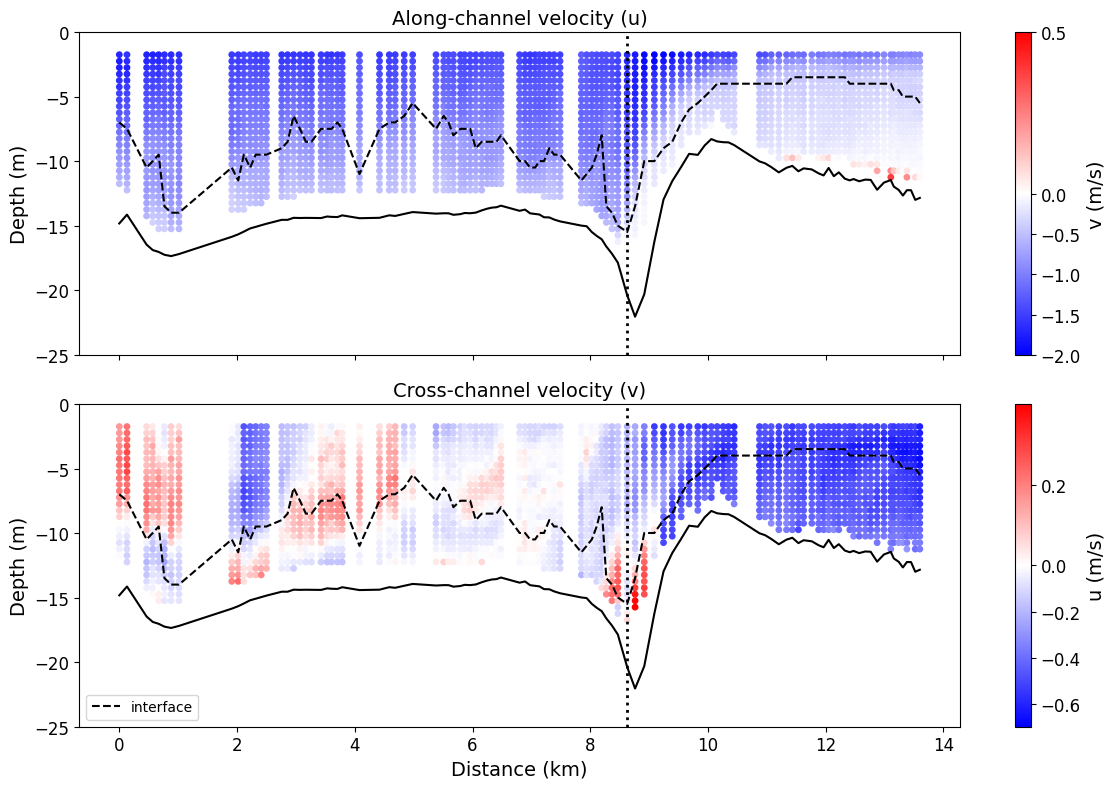

In [21]:
# --- Choosing every detail to make the most pretty diagram ---
#Depht configuration and fontsize defined on previous cells (Y axis):

# --- Adjusting color contrast (it was too pale in previous versions) ---

# Upper diagram (Along-channel velocity 'u' - corr_long)
# Vmin adjusted to -1.5 to increase blue contrast 
norm_v_new = mcolors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=0.5) 

# Bottom diagram (Cross-channel velocity 'v' - corr_across)
# Vmax adjusted to highlight positive (red) valuesnorm_u_new = mcolors.TwoSlopeNorm(vmin=-0.7, vcenter=0, vmax=0.4) 


# --- CREATING THE PLPOT---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# === PLOTING DATA AND INTERFACE (PYCNOCLINE) ===

# Diagram 1: Along-channel velocity (u)
cb1 = axs[0].scatter(corr_x, -corr_z, s=15, c=corr_long, cmap='bwr', norm=norm_v_new)
axs[0].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') 
axs[0].tick_params(axis='both', which='major', labelsize=fontsize_ticks) # Axis label
axs[0].set_title('Along-channel velocity (u)', fontsize=fontsize_main)

# Diagram 2: Cross-channel velocity (v)
cb2 = axs[1].scatter(corr_x, -corr_z, s=15, c=corr_across, cmap='bwr', norm=norm_u_new)
axs[1].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') 
axs[1].tick_params(axis='both', which='major', labelsize=fontsize_ticks) # Axis label
axs[1].set_title('Cross-channel velocity (v)',fontsize=fontsize_main)


# --- using plot_sets ---
# The plot_sets function should be invoked at this point to guarantee the plotting of the bathymetry and initial boundaries
plot_sets(axs[0])
plot_sets(axs[1])

# --- FINAL CONFIGURATION OF Y AXIS (plot_sets) ---
# This order matter to guarantee the ticks interval (in 5-5 meters)
# Define the limits (guarantee the interval between -24 to 0 even if plot_sets change)
axs[0].set_ylim(y_min, y_max) 
axs[1].set_ylim(y_min, y_max)

# Forces 5 - 5 meters interval in Y axis: 
axs[0].set_yticks(y_ticks) 
axs[1].set_yticks(y_ticks)

# --- CONFIG LABELS and LEGENDS ---

# X axis:
axs[0].tick_params(labelbottom=False) # Remove numbers X from the upper diagram
axs[0].set_xlabel('')
axs[1].set_xlabel('Distance (km)', fontsize=fontsize_main) # Label X only in bottom diagram

# Y axis: 
axs[0].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[1].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[1].legend(loc='lower left') # Add legend at the bottom (interface)

# Colorbars
cbar1 = fig.colorbar(cb1, ax=axs[0], label='v (m/s)')
cbar1.set_label('v (m/s)', fontsize=fontsize_main)
cbar1.ax.tick_params(labelsize=fontsize_ticks)

cbar2 = fig.colorbar(cb2, ax=axs[1], label='u (m/s)')
cbar2.set_label('u (m/s)', fontsize=fontsize_main)
cbar2.ax.tick_params(labelsize=fontsize_ticks)


# --- saving ---
plt.tight_layout()
plt.savefig(os.path.join(output_image,'PAPER_drift_along_and_cross_velocity.png'), dpi=300)
plt.show()

## **Epsilon:**



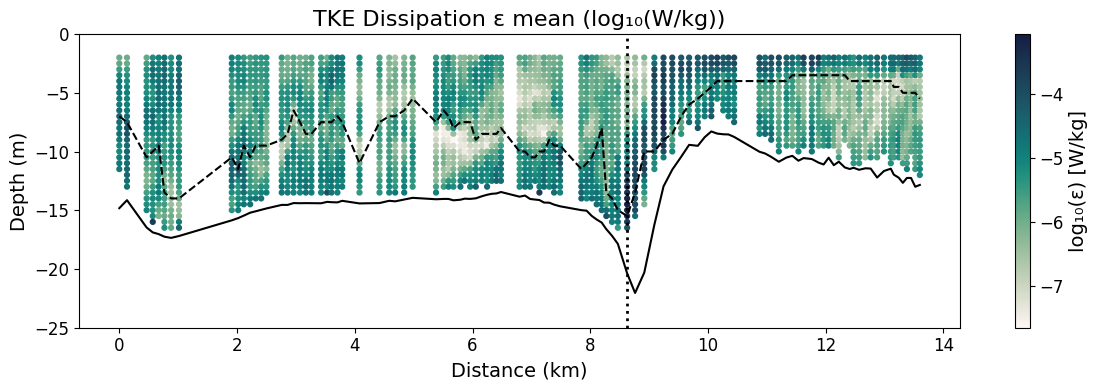

In [22]:
#Depht configuration and fontsize defined on previous cells (Y axis):

fig, ax = plt.subplots(figsize=(12, 4))
cb = ax.scatter(x_calc, -z_calc, s=12, c=np.log10(Epsilon), cmap=cmocean.cm.tempo)
ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks) # axis label

# Add interface
ax.plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # adding pycnocline here

# Define limits (guarantee -24 to 0, if plot_sets change)
ax.set_ylim(y_min, y_max) 

# Forces 5 - 5 meters interval in Y axis: 
ax.set_yticks(y_ticks) 

plot_sets(ax)
ax.set_title('TKE Dissipation ε mean (log₁₀(W/kg))', fontsize=fontsize_title)
ax.set_xlabel('Distance (km)', fontsize=fontsize_main)
ax.set_ylabel('Depth (m)', fontsize=fontsize_main)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('log₁₀(ε) [W/kg]', fontsize=fontsize_main)
cbar.ax.tick_params(labelsize=fontsize_ticks)


plt.tight_layout()
plt.savefig(os.path.join(output_image,'PAPER_drift_mean_TKE.png'), dpi=300)
plt.show()

## **Calculated Variables:**



/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_38401/3973267819.py:8: RuntimeWarning: invalid value encountered in log10
  c=np.log10(N2), cmap=cmocean.cm.thermal)
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_38401/3973267819.py:31: RuntimeWarning: invalid value encountered in log10
  c=np.log10(Ri), cmap='bwr', norm=norm)


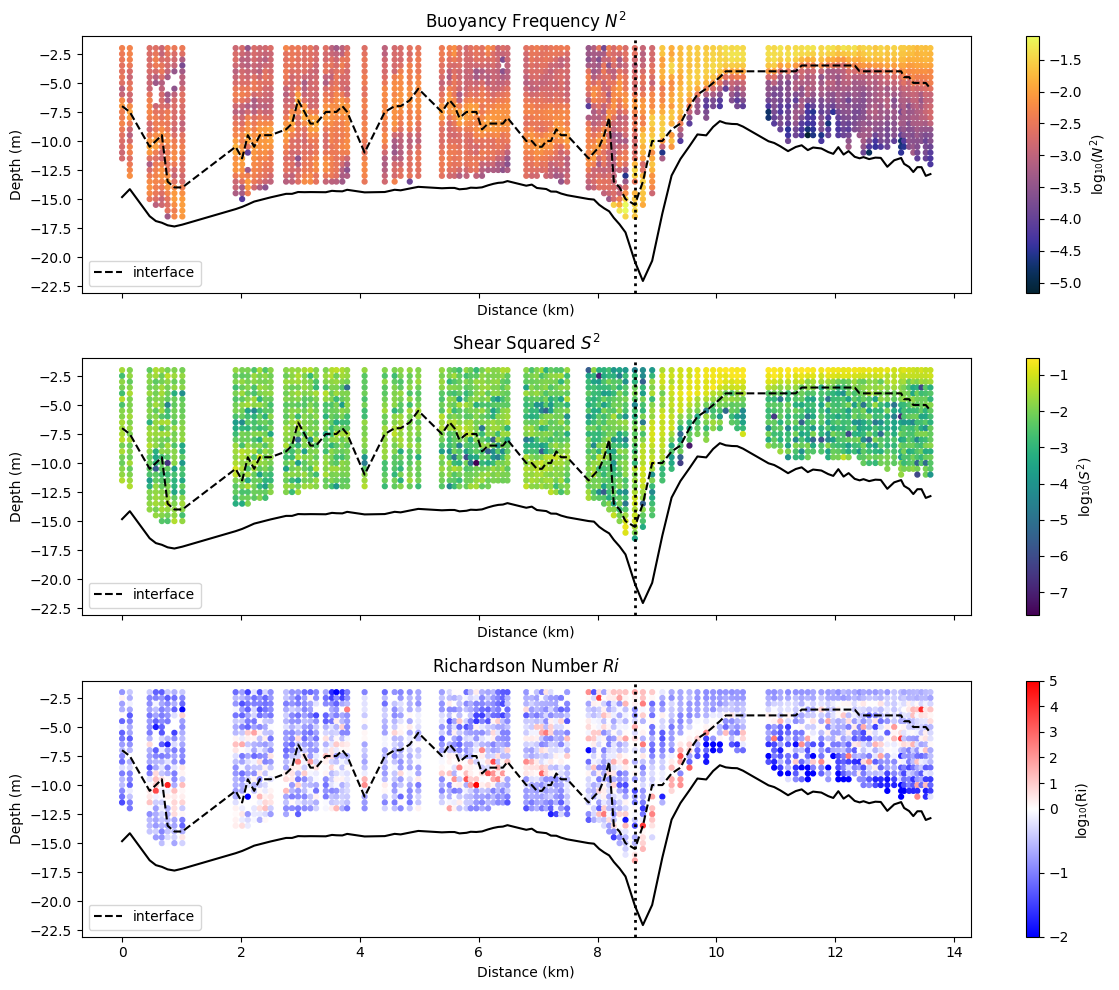

In [31]:
#Depht configuration and fontsize defined on previous cells (Y axis):

# --- Code to plot calculated variables:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# === Buoyancy Frequency (N²) ===
cb = axs[0].scatter(x_calc, -z_calc, s=12,
                     c=np.log10(N2), cmap=cmocean.cm.thermal)
axs[0].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # Add pycnocline here
plot_sets(axs[0])
axs[0].set_title('Buoyancy Frequency $N^2$')
axs[0].set_ylabel('Depth (m)')
axs[0].legend()
fig.colorbar(cb, ax=axs[0], label='log₁₀($N^2$)')

# === Squared Shear (S²) ===
cb = axs[1].scatter(x_calc, -z_calc, s=12,
                     c=np.log10(S2), cmap='viridis')
axs[1].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # Add pycnocline here
plot_sets(axs[1])
axs[1].set_title('Shear Squared $S^2$')
axs[1].set_ylabel('Depth (m)')
axs[1].legend()
fig.colorbar(cb, ax=axs[1], label='log₁₀($S^2$)')

# === Ri / 0.25 ===
vmin = -2
vmax = 5
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cb = axs[2].scatter(x_calc, -z_calc, s=12,
                     c=np.log10(Ri), cmap='bwr', norm=norm)
axs[2].plot(dist_pic_Fr, -pic, color='k', linewidth=1.5, linestyle='--', label='interface') # Add pycnocline here
plot_sets(axs[2])
axs[2].set_title('Richardson Number $Ri$')
axs[2].set_ylabel('Depth (m)')
axs[2].legend()
fig.colorbar(cb, ax=axs[2], label='log₁₀(Ri)')

# === Eddy Viscosity (A_z) ===
#cb = axs[3].scatter(x_calc, -z_calc, s=12,
                     #c=np.log10(Az), cmap=cmocean.cm.thermal_r)
#axs[3].scatter(dist_pic_Fr, -pic, color='k', s=30, marker='o', label='pycnocline') # Adicionando os pontos da picnoclina aqui
#plot_sets(axs[3])
#axs[3].set_title('Eddy Viscosity $A_z$')
#axs[3].set_ylabel('Depth (m)')
#axs[3].set_xlabel('Distance (km)')
#axs[3].legend()
#fig.colorbar(cb, ax=axs[3], label='(log₁₀($m^2/s$)')

plt.tight_layout()
plt.savefig(os.path.join(output_image,'PAPER_drift_mean_TKE.png'), dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_38401/3745478804.py:8: RuntimeWarning: invalid value encountered in log10
  c=np.log10(N2), cmap=cmocean.cm.thermal)
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_38401/3745478804.py:38: RuntimeWarning: invalid value encountered in log10
  c=np.log10(Ri/0.25), cmap='bwr', norm=norm)


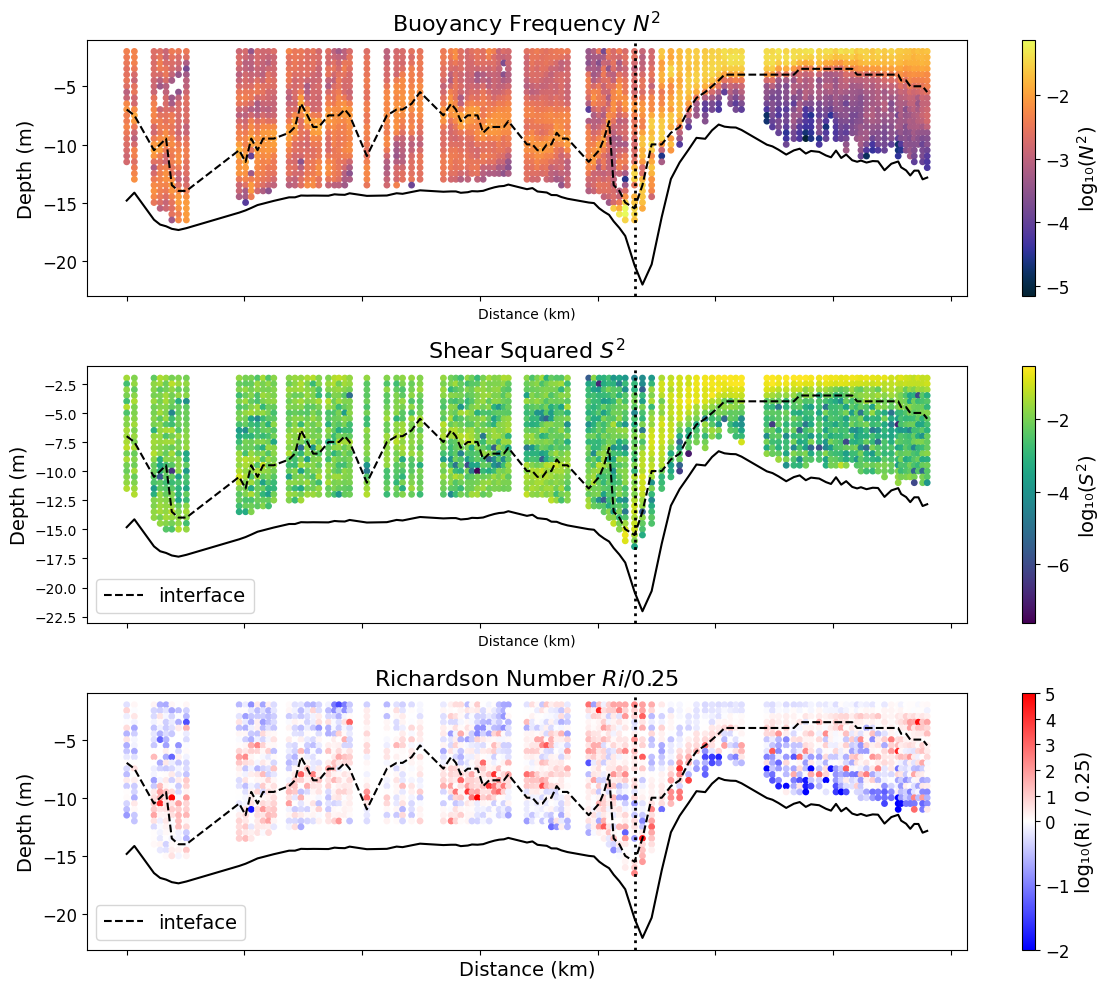

In [32]:
#Depht configuration and fontsize defined on previous cells (Y axis):

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)


# === Buoyancy Frequency (N²) ===
cb = axs[0].scatter(x_calc, -z_calc, s=15,
                     c=np.log10(N2), cmap=cmocean.cm.thermal)
axs[0].plot(dist_pic_Fr, -pic, color='k', linestyle='--', linewidth=1.5,label='interface') # Add pycnocline here 
plot_sets(axs[0])
axs[0].set_title('Buoyancy Frequency $N^2$', fontsize=fontsize_title)
axs[0].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[0].tick_params(labelbottom=False) # Remove X numbers from the upper diagram 
cbar = fig.colorbar(cb, ax=axs[0])
cbar.set_label('log₁₀($N^2$)', fontsize=fontsize_main) # Colorbar label
cbar.ax.tick_params(labelsize=fontsize_ticks) # Colorbar numbers

# === Squared Shear (S²) ===
cb = axs[1].scatter(x_calc, -z_calc, s=15,
                     c=np.log10(S2), cmap='viridis')
axs[1].plot(dist_pic_Fr, -pic, color='k', linestyle='--', linewidth=1.5,label='interface') # Add pycnocline here 
plot_sets(axs[1])
axs[1].set_title('Shear Squared $S^2$',fontsize=fontsize_title)
axs[1].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[1].tick_params(labelbottom=False) # Remove X numbers from the upper diagram 
axs[1].legend(fontsize=fontsize_main)
cbar = fig.colorbar(cb, ax=axs[1])
cbar.set_label('log₁₀($S^2$)', fontsize=fontsize_main) # Colorbar label
cbar.ax.tick_params(labelsize=fontsize_ticks) # Colorbar numbers


# === Ri / 0.25 ===
# ADJUST LIMITS TO FOCUS ON "CENTER" and reduce scale: 
#vmin = -1.5 # Antes: -2. Focus more on instabilitiy region (Ri << 0.25)
#vmax = 2.5  # Antes: 5. Reduce upper scale, highlighting more Ri=0 .
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cb = axs[2].scatter(x_calc, -z_calc, s=15,
                     c=np.log10(Ri/0.25), cmap='bwr', norm=norm)
axs[2].plot(dist_pic_Fr, -pic, color='k', linestyle='--', linewidth=1.5,label='inteface') # Add pycnocline here 
plot_sets(axs[2])
axs[2].set_title('Richardson Number $Ri/0.25$',fontsize=fontsize_title)
axs[2].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[2].tick_params(axis='both', which='major', labelsize=fontsize_ticks) # axis labels
axs[2].tick_params(labelbottom=False) # Remove X numbers from the upper diagram 
axs[2].legend(fontsize=fontsize_main)
axs[2].set_xlabel('Distance (km)',fontsize=fontsize_main) # Label X only at bottom diagram
cbar = fig.colorbar(cb, ax=axs[2])
cbar.set_label('log₁₀(Ri / 0.25)', fontsize=fontsize_main) # Colorbar label
cbar.ax.tick_params(labelsize=fontsize_ticks) # Colorbar numbers

axs[0].tick_params(axis='both', which='major', labelsize=fontsize_ticks) # axis label
axs[0].tick_params(labelbottom=False) # Remove os números X do gráfico superior


plt.tight_layout()
plt.savefig(os.path.join(output_image,'PAPER_drift_mean_TKE_opB.png'), dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/2998557668.py:19: RuntimeWarning: invalid value encountered in log10
  cb = axs[0].scatter(x_calc, -z_calc, s=15, c=np.log10(N2), cmap=cmocean.cm.thermal)
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/2998557668.py:49: RuntimeWarning: invalid value encountered in log10
  cb = axs[2].scatter(x_calc, -z_calc, s=15, c=np.log10(Ri/0.25), cmap='bwr', norm=norm)


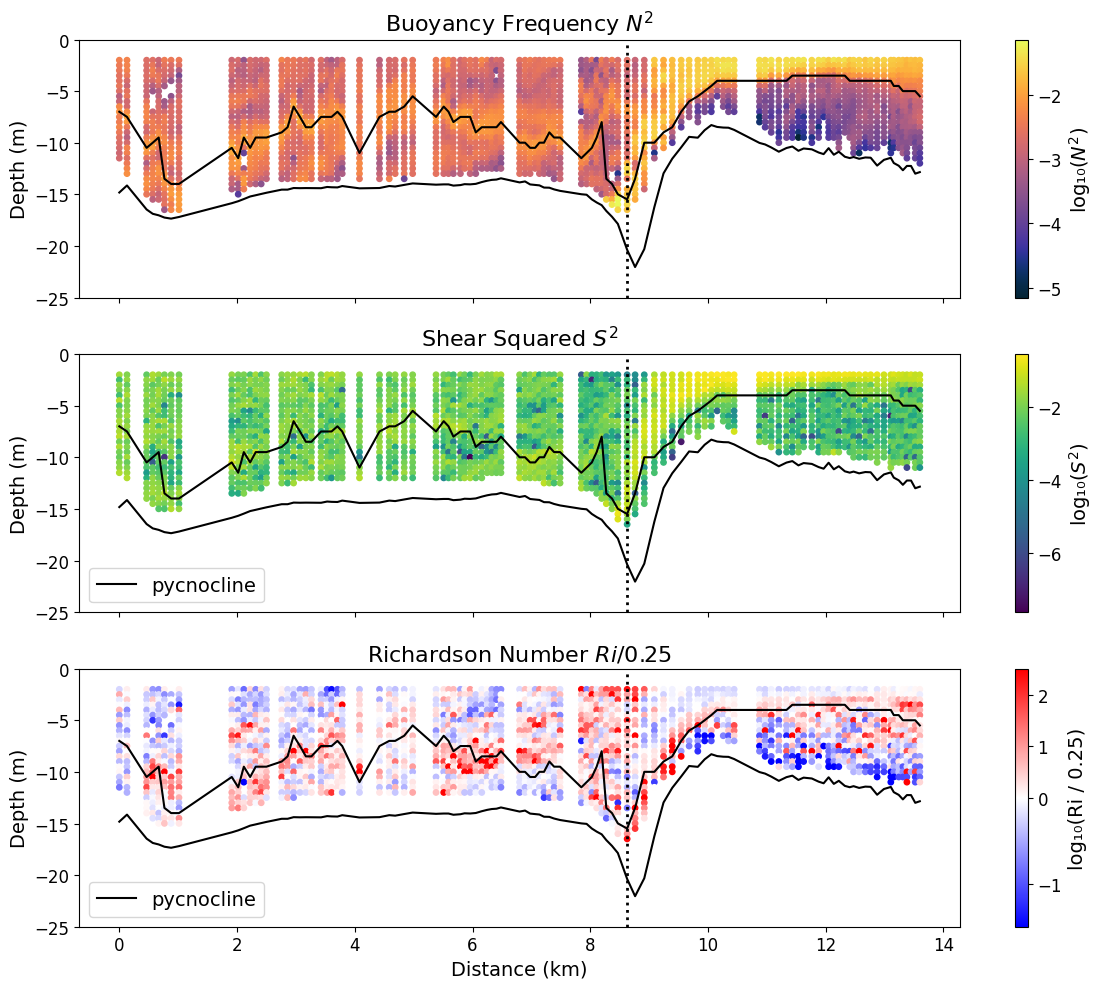

In [21]:
# --- Variáveis (Assumindo que N2, S2, Ri, x_calc, z_calc, dist_pic_Fr, pic estão definidos) ---

#======= kit embelezamento do grafico======:
# Configuração da Faixa de Profundidade (Eixo Y)
y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)

# Defina o tamanho de fonte principal desejado
fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 
#===========================================

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# === Buoyancy Frequency (N²) ===
cb = axs[0].scatter(x_calc, -z_calc, s=15, c=np.log10(N2), cmap=cmocean.cm.thermal)
axs[0].plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline')
plot_sets(axs[0])
axs[0].set_title('Buoyancy Frequency $N^2$', fontsize=fontsize_title)
axs[0].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[0].tick_params(axis='y', which='major', labelsize=fontsize_ticks) # Ticks do Y
axs[0].tick_params(labelbottom=False) # Remove números X
cbar = fig.colorbar(cb, ax=axs[0])
cbar.set_label('log₁₀($N^2$)', fontsize=fontsize_main) 
cbar.ax.tick_params(labelsize=fontsize_ticks) 


# === Squared Shear (S²) ===
cb = axs[1].scatter(x_calc, -z_calc, s=15, c=np.log10(S2), cmap='viridis')
axs[1].plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline')
plot_sets(axs[1])
axs[1].set_title('Shear Squared $S^2$',fontsize=fontsize_title)
axs[1].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[1].tick_params(axis='y', which='major', labelsize=fontsize_ticks) # Ticks do Y
axs[1].tick_params(labelbottom=False) # Remove números X
axs[1].legend(fontsize=fontsize_main)
cbar = fig.colorbar(cb, ax=axs[1])
cbar.set_label('log₁₀($S^2$)', fontsize=fontsize_main)
cbar.ax.tick_params(labelsize=fontsize_ticks)


# === Ri / 0.25 ===
vmin = -1.5 
vmax = 2.5
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cb = axs[2].scatter(x_calc, -z_calc, s=15, c=np.log10(Ri/0.25), cmap='bwr', norm=norm)
axs[2].plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline')
plot_sets(axs[2])
axs[2].set_title('Richardson Number $Ri/0.25$',fontsize=fontsize_title)
axs[2].set_ylabel('Depth (m)',fontsize=fontsize_main)
axs[2].tick_params(axis='both', which='major', labelsize=fontsize_ticks) # Ticks do X e Y
axs[2].legend(fontsize=fontsize_main)
axs[2].set_xlabel('Distance (km)',fontsize=fontsize_main) # Label X AQUI

cbar = fig.colorbar(cb, ax=axs[2])
cbar.set_label('log₁₀(Ri / 0.25)', fontsize=fontsize_main) 
cbar.ax.tick_params(labelsize=fontsize_ticks) 

# -------------------------------------------------------------
# 🎯 CORREÇÃO FINAL PARA AXIS E LABELS (APÓS plot_sets)
# -------------------------------------------------------------

# 1. FORÇAR LIMITES E TICKS (Y) IGUAIS PARA TODOS OS PLOTS (RESOLVE DESALINHAMENTO Y)
for ax in axs:
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(y_ticks)
    # Garante que os ticks do Y sejam no tamanho correto (já que foram sobrepostos)
    ax.tick_params(axis='y', which='major', labelsize=fontsize_ticks)
    
# 2. LIMPAR LABELS X DOS SUPERIORES (RESOLVE LABEL NO MEIO)
axs[0].set_xlabel('')
axs[1].set_xlabel('')
# Apenas axs[2] manterá o label 'Distance (km)' definido acima

plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Drift_N_S_Ri_calc_vs_distance3_FINAL.png", dpi=300)
plt.show()

## Calculating Buoyancy Reynold number (Reb):

Since Az didn't highlight the key processes well, I recalculated the Buoyancy Reynolds Number instead.

In [33]:
Reb = Epsilon / (((10)**(-6))*N2)

In [34]:
len (Reb)

2279

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/1298292508.py:11: RuntimeWarning: invalid value encountered in log10
  c=np.log10(Az), cmap=cmocean.cm.thermal_r)


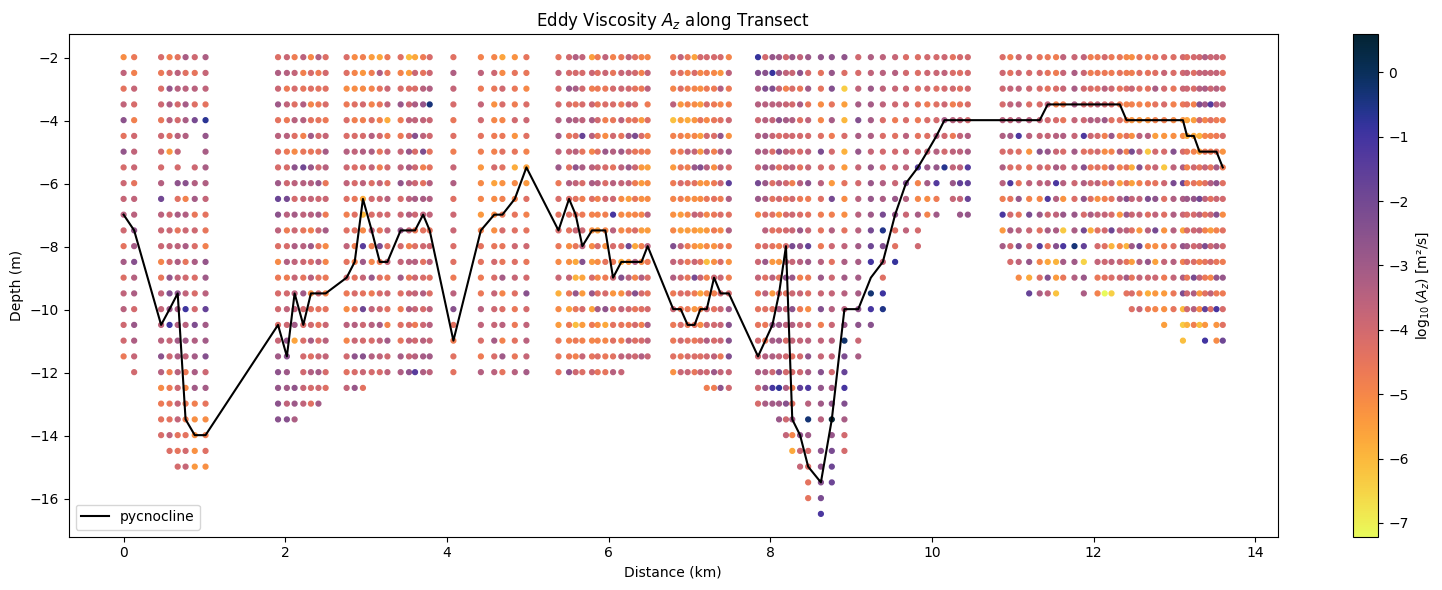

In [24]:
# =================================================================
# BLOCO DE PLOTAGEM DE AZ (CORRIGIDO)
# =================================================================

# Inicializa o subplot (agora com apenas um eixo, 'ax')
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# 1. PLOTAGEM PRINCIPAL: Vertical Eddy Viscosity (Az)
# (Assumimos que x_calc, z_calc, Az e cmocean.cm.thermal_r estão definidos)
cb = ax.scatter(x_calc, -z_calc, s=12,
                c=np.log10(Az), cmap=cmocean.cm.thermal_r)

# 2. PLOTAGEM DA PICNOCLINA (Linha Discreta)
# (Assumimos que dist_pic_Fr e pic estão definidos)
ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,
        label='pycnocline') 

# 3. CHAMADA À FUNÇÃO PLOT_SETS
# (A função plot_sets DEVE ser definida antes de rodar este bloco)
# plot_sets(ax) # Descomente se a função estiver definida no seu notebook

# --- Configurações Finais ---
# Os títulos e rótulos agora estão definidos apenas uma vez e corretamente

ax.set_title(r'Eddy Viscosity $A_z$ along Transect') # Título específico
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Depth (m)')
ax.legend(loc='lower left')

# Adiciona a barra de cores
# Usando o rótulo de S^2 que você tinha (embora Az e S^2 sejam diferentes)
fig.colorbar(cb, ax=ax, label=r'$\log_{10}(A_z)$ [m²/s]') 


plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Az_c.png", dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/1381669359.py:9: RuntimeWarning: invalid value encountered in log10
  cb = ax.scatter(x_calc, -z_calc, s=12, c=np.log10(Az), cmap=cmocean.cm.thermal_r)


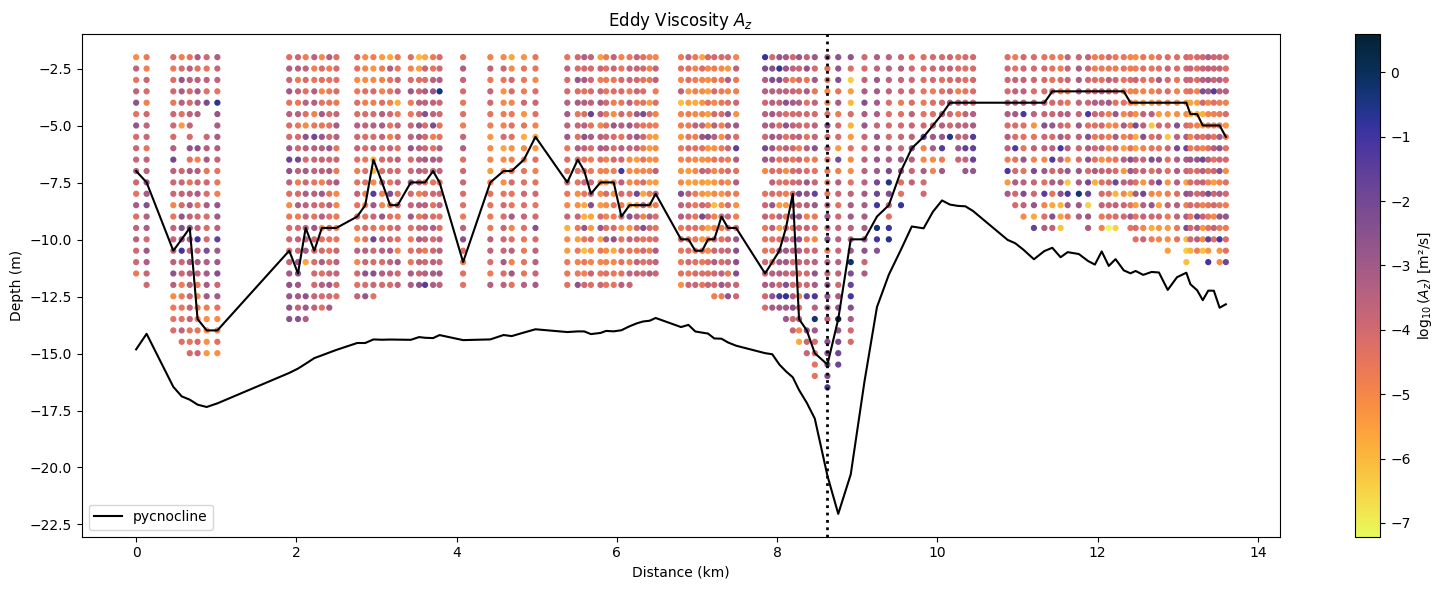

In [25]:

# Inicializa o subplot (agora com apenas um eixo, 'ax')
fig, ax = plt.subplots(1, 1, figsize=(16, 6))


#================================================
#    PLOT 1: Vertical Eddy Viscosity (Az)
#================================================

cb = ax.scatter(x_calc, -z_calc, s=12, c=np.log10(Az), cmap=cmocean.cm.thermal_r)
ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline') 
#ax.scatter(dist_pic_Fr, -pic, color='k', s=30, marker='o', label='pycnocline') # Adicionando os pontos da picnoclina aqui

ax.set_title('Eddy Viscosity $A_z$')
ax.set_ylabel('Depth (m)')
ax.legend()
fig.colorbar(cb, ax=axs[0], label='log₁₀($S^2$)')
ax.set_xlabel('Distance (km)')

# --- Nova Picnoclina Discreta (Linha Simples) ---
# Mudamos o scatter para plotar a linha da picnoclina:
#ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline') 
# Se você realmente quiser manter os marcadores PONTOS PRETOS discretos:
# ax.scatter(dist_pic_Fr, -pic, color='k', s=8, marker='.') 

plot_sets(ax)

# Adiciona a barra de cores
# Usando o rótulo de S^2 que você tinha (embora Az e S^2 sejam diferentes)
fig.colorbar(cb, ax=ax, label=r'$\log_{10}(A_z)$ [m²/s]') 

plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Azfinal.png", dpi=300)
plt.show()



/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/1477225931.py:26: RuntimeWarning: invalid value encountered in log10
  cb = ax.scatter(x_calc, -z_calc, s=dot_size_data, c=np.log10(Az), cmap=cmocean.cm.thermal_r)


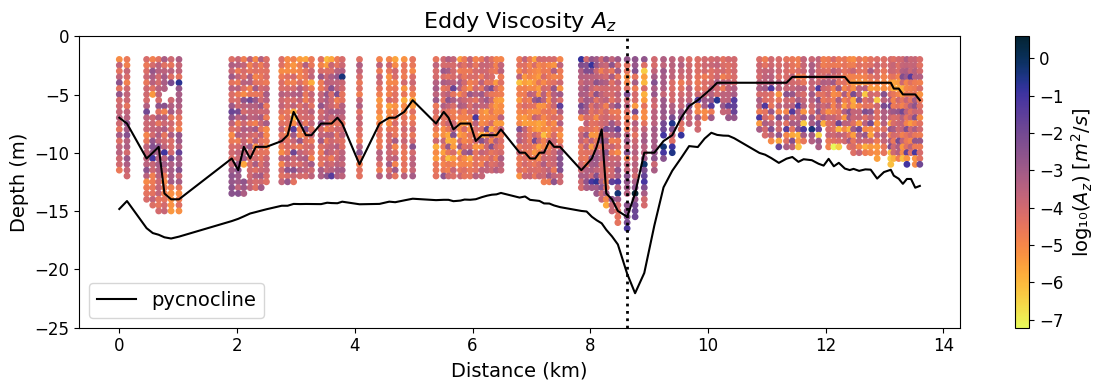

In [26]:
# --- CONFIGURAÇÕES VISUAIS GLOBAIS (Reutilizadas) ---

# Configuração da Faixa de Profundidade (Eixo Y)
y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)

# Defina o tamanho de fonte principal desejado
fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 

# Tamanho das bolinhas
dot_size_data = 15      # Tamanho para os dados
dot_size_picnocline = 50 # Tamanho para a picnoclina (se for scatter)
#====================================================

# Inicializa o subplot
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

#================================================
#      PLOT 1: Vertical Eddy Viscosity (Az)
#================================================

cb = ax.scatter(x_calc, -z_calc, s=dot_size_data, c=np.log10(Az), cmap=cmocean.cm.thermal_r)
ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5, label='pycnocline') 

# Títulos e Labels
ax.set_title('Eddy Viscosity $A_z$', fontsize=fontsize_title)
ax.set_ylabel('Depth (m)', fontsize=fontsize_main)
ax.set_xlabel('Distance (km)', fontsize=fontsize_main)
ax.legend(fontsize=fontsize_main) # Aplica tamanho da fonte na legenda

# Aplica a função customizada (batimetria e limites iniciais)
plot_sets(ax)

# --- CONFIGURAÇÃO FINAL DOS EIXOS (Padronização) ---
# Garante que os limites e ticks sejam os mesmos de todos os gráficos
ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)
ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks) # Ticks do X e Y

# --- CONFIGURAÇÃO DA COLORBAR ---
cbar = fig.colorbar(cb, ax=ax, label='log₁₀($A_z$) [$m^2/s$]') 
# Configura o tamanho da fonte do rótulo da colorbar
cbar.set_label('log₁₀($A_z$) [$m^2/s$]', fontsize=fontsize_main)
# Configura o tamanho dos números (ticks) da colorbar
cbar.ax.tick_params(labelsize=fontsize_ticks)

# --- FINALIZAÇÃO ---
plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Azfinal_padronizado.png", dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/3706759841.py:42: RuntimeWarning: invalid value encountered in log10
  cb = ax.scatter(x_calc, -z_calc, s=dot_size_data, c=np.log10(Az), cmap=cmap_az, norm=norm_az)


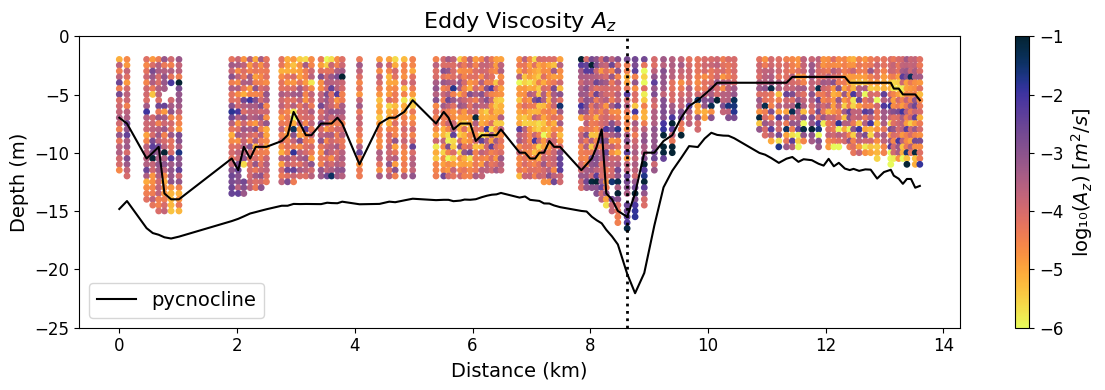

In [27]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import cmocean

# --- CONFIGURAÇÕES VISUAIS GLOBAIS (Reutilizadas) ---
y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)

fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 

dot_size_data = 15      
dot_size_picnocline = 50 
#====================================================

# Inicializa o subplot
fig, ax = plt.subplots(1, 1, figsize=(12,4))

#================================================
#      PLOT 1: Vertical Eddy Viscosity (Az)
#================================================

# 🔑 AJUSTE AQUI: Definir vmin e vmax para a colorbar
# Olhando o gráfico, os valores parecem ir de -7 a 0.
# Se a maioria dos seus dados relevantes está entre -6 e -1, podemos usar esses limites
# Isso fará com que as cores fiquem mais saturadas dentro dessa faixa.
az_vmin = -6.0 # Ajustado para realçar a variação dentro da faixa mais comum
az_vmax = -1.0 # Ajustado para realçar a variação dentro da faixa mais comum

# Se você quiser explorar outros cmaps para maior contraste:
# cmap_az = cmocean.cm.amp # Boa para realçar contraste
# cmap_az = cmocean.cm.dense_r # Boa para realçar contraste (reversa)
# cmap_az = 'magma' # Ou 'viridis', 'plasma', etc.
cmap_az = cmocean.cm.thermal_r # Mantendo o seu original, mas focado nos limites.

# Cria a colorbar normalizada com os novos vmin/vmax
norm_az = mcolors.Normalize(vmin=az_vmin, vmax=az_vmax)
cb = ax.scatter(x_calc, -z_calc, s=dot_size_data, c=np.log10(Az), cmap=cmap_az, norm=norm_az)
ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5, label='pycnocline') 

# Títulos e Labels (mantidos)
ax.set_title('Eddy Viscosity $A_z$', fontsize=fontsize_title)
ax.set_ylabel('Depth (m)', fontsize=fontsize_main)
ax.set_xlabel('Distance (km)', fontsize=fontsize_main)
ax.legend(fontsize=fontsize_main) 

plot_sets(ax)

# --- CONFIGURAÇÃO FINAL DOS EIXOS (Padronização) ---
ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)
ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks) 

# --- CONFIGURAÇÃO DA COLORBAR ---
cbar = fig.colorbar(cb, ax=ax) # Removi o label daqui para setar separado
cbar.set_label('log₁₀($A_z$) [$m^2/s$]', fontsize=fontsize_main)
cbar.ax.tick_params(labelsize=fontsize_ticks)

# --- FINALIZAÇÃO ---
plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Azfinal_alto_contraste.png", dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_17995/2119204712.py:35: RuntimeWarning: invalid value encountered in log10
  c=np.log10(Az), cmap=cmocean.cm.thermal_r, norm=norm_az) # Aplicando norm_az e dot_size
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_17995/2119204712.py:61: RuntimeWarning: invalid value encountered in log10
  log_Reb = np.log10(Reb)


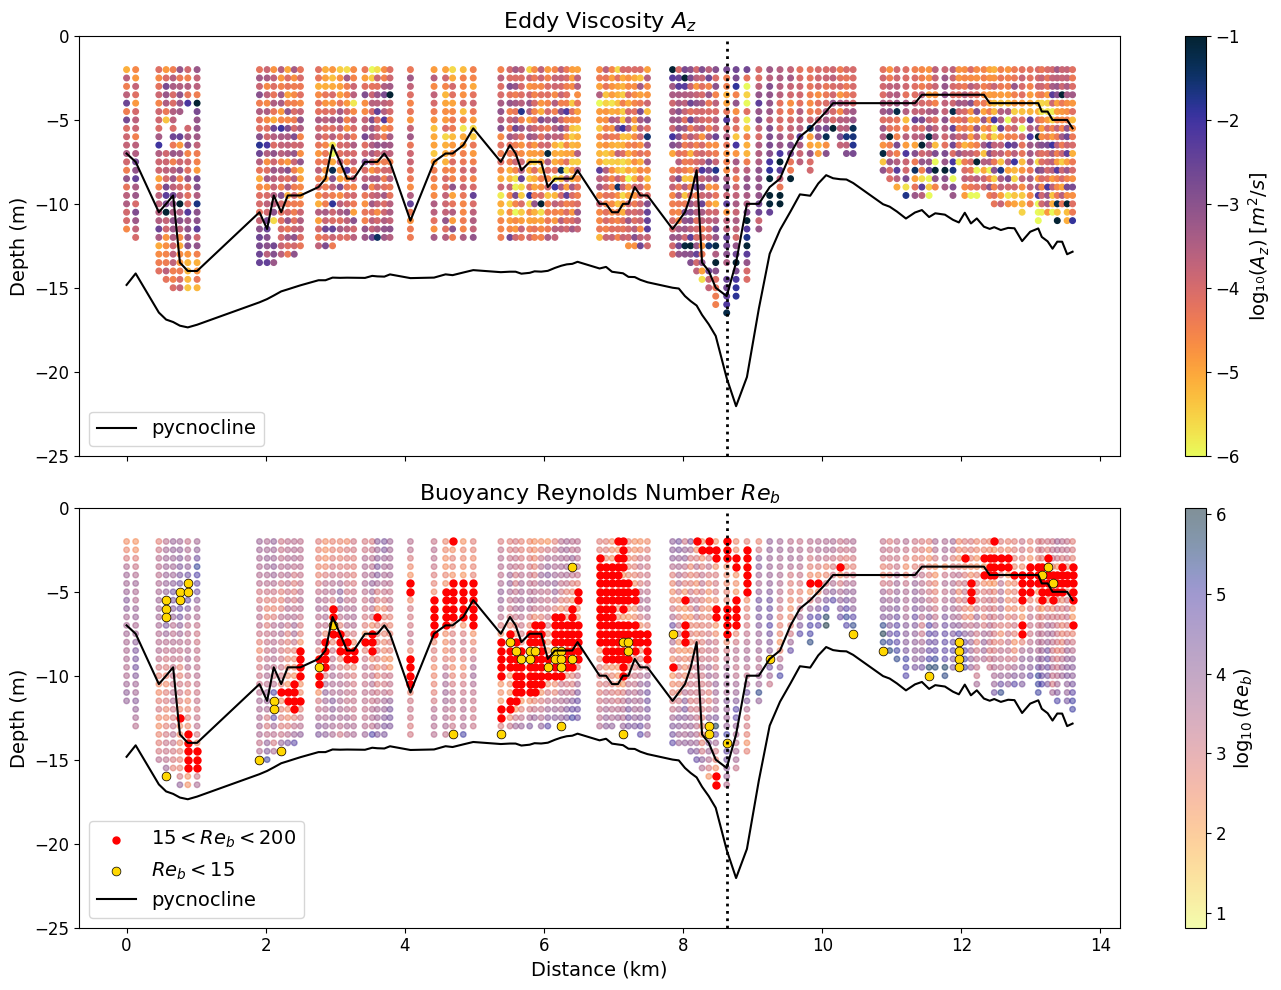

In [26]:
# --- CONFIGURAÇÕES VISUAIS GLOBAIS (Padrão) ---

# Configuração da Faixa de Profundidade (Eixo Y)
y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)

# Tamanhos de Fonte
fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 

# Tamanhos de Marcadores
dot_size_data_Az = 16       # Aumentado para Az
dot_size_data_Reb_base = 16 
#====================================================

# --- AJUSTES DA COLORBAR ---
# Ajuste de contraste para Az (Viscosidade, como discutido)
az_vmin = -6.0 
az_vmax = -1.0 
norm_az = mcolors.Normalize(vmin=az_vmin, vmax=az_vmax)
#-----------------------------

# --- CRIAÇÃO DA FIGURA ---
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)


#================================================
# 🎯 PLOT 1: Vertical Eddy Viscosity (Az) - axs[0]
#================================================

cb1 = axs[0].scatter(x_calc, -z_calc, s=dot_size_data_Az,
                     c=np.log10(Az), cmap=cmocean.cm.thermal_r, norm=norm_az) # Aplicando norm_az e dot_size
axs[0].plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline') 
plot_sets(axs[0])

# Títulos e Labels
axs[0].set_title('Eddy Viscosity $A_z$', fontsize=fontsize_title)
axs[0].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[0].legend(fontsize=fontsize_main)

# Ticks e Eixo X (Superior)
axs[0].tick_params(axis='both', which='major', labelsize=fontsize_ticks)
axs[0].tick_params(labelbottom=False) 

# Configuração da Colorbar 1
cbar1 = fig.colorbar(cb1, ax=axs[0])
cbar1.set_label('log₁₀($A_z$) [$m^2/s$]', fontsize=fontsize_main) # Rótulo corrigido para Az
cbar1.ax.tick_params(labelsize=fontsize_ticks)


#================================================
# 🎯 PLOT 2: buoyancy Reynold number (Reb) - axs[1]
#================================================

# --- Variáveis de Reb (Mantidas) ---
LOG_REB_200 = np.log10(200)
LOG_REB_15 = np.log10(15)
log_Reb = np.log10(Reb)
idx_low_turb = (Reb < 200)
idx_very_low_turb = (Reb < 15)

# Passo 1: Plotar todos os pontos (Fundo) com OPACIDADE REDUZIDA
cb2 = axs[1].scatter(x_calc, -z_calc, s=dot_size_data_Reb_base, 
                     c=log_Reb, cmap=cmocean.cm.thermal_r,
                     alpha=0.5) 

# Passo 2 & 3: Plotar os pontos de turbulência realçados
axs[1].scatter(x_calc[idx_low_turb], -z_calc[idx_low_turb],
               s=25, marker='o', color='red',
               label=r'$15 < Re_b < 200$')
axs[1].scatter(x_calc[idx_very_low_turb], -z_calc[idx_very_low_turb],
               s=40, marker='o', color='gold', edgecolor='k', linewidth=0.5,
               label=r'$Re_b < 15$')

# Picnoclina
axs[1].plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,
            label='pycnocline') 
plot_sets(axs[1])

# Títulos e Labels
axs[1].set_title(r'Buoyancy Reynolds Number $Re_b$', fontsize=fontsize_title)
axs[1].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[1].set_xlabel('Distance (km)', fontsize=fontsize_main) # Label X AQUI
axs[1].legend(loc='lower left', fontsize=fontsize_main) # Tamanho da fonte na legenda

# Ticks e Eixo X (Inferior)
axs[1].tick_params(axis='both', which='major', labelsize=fontsize_ticks)

# Configuração da Colorbar 2
cbar2 = fig.colorbar(cb2, ax=axs[1])
cbar2.set_label(r'$\log_{10}(Re_b)$', fontsize=fontsize_main)
cbar2.ax.tick_params(labelsize=fontsize_ticks)


# -------------------------------------------------------------
# 🎯 CORREÇÃO FINAL PARA AXIS E LABELS (APÓS plot_sets)
# -------------------------------------------------------------
# 1. FORÇAR LIMITES E TICKS (Y) IGUAIS PARA AMBOS OS PLOTS
for ax in axs:
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(y_ticks)
    # Garante que os ticks do Y sejam no tamanho correto (pode ser redundante, mas garante)
    ax.tick_params(axis='y', which='major', labelsize=fontsize_ticks)

# 2. LIMPAR LABEL X DO SUPERIOR (Já deve estar limpo, mas garante)
axs[0].set_xlabel('')


plt.tight_layout()
#plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/AzXReb3_FINAL_PADRONIZADO.png", dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_17995/162168556.py:36: RuntimeWarning: invalid value encountered in log10
  c=np.log10(Az),


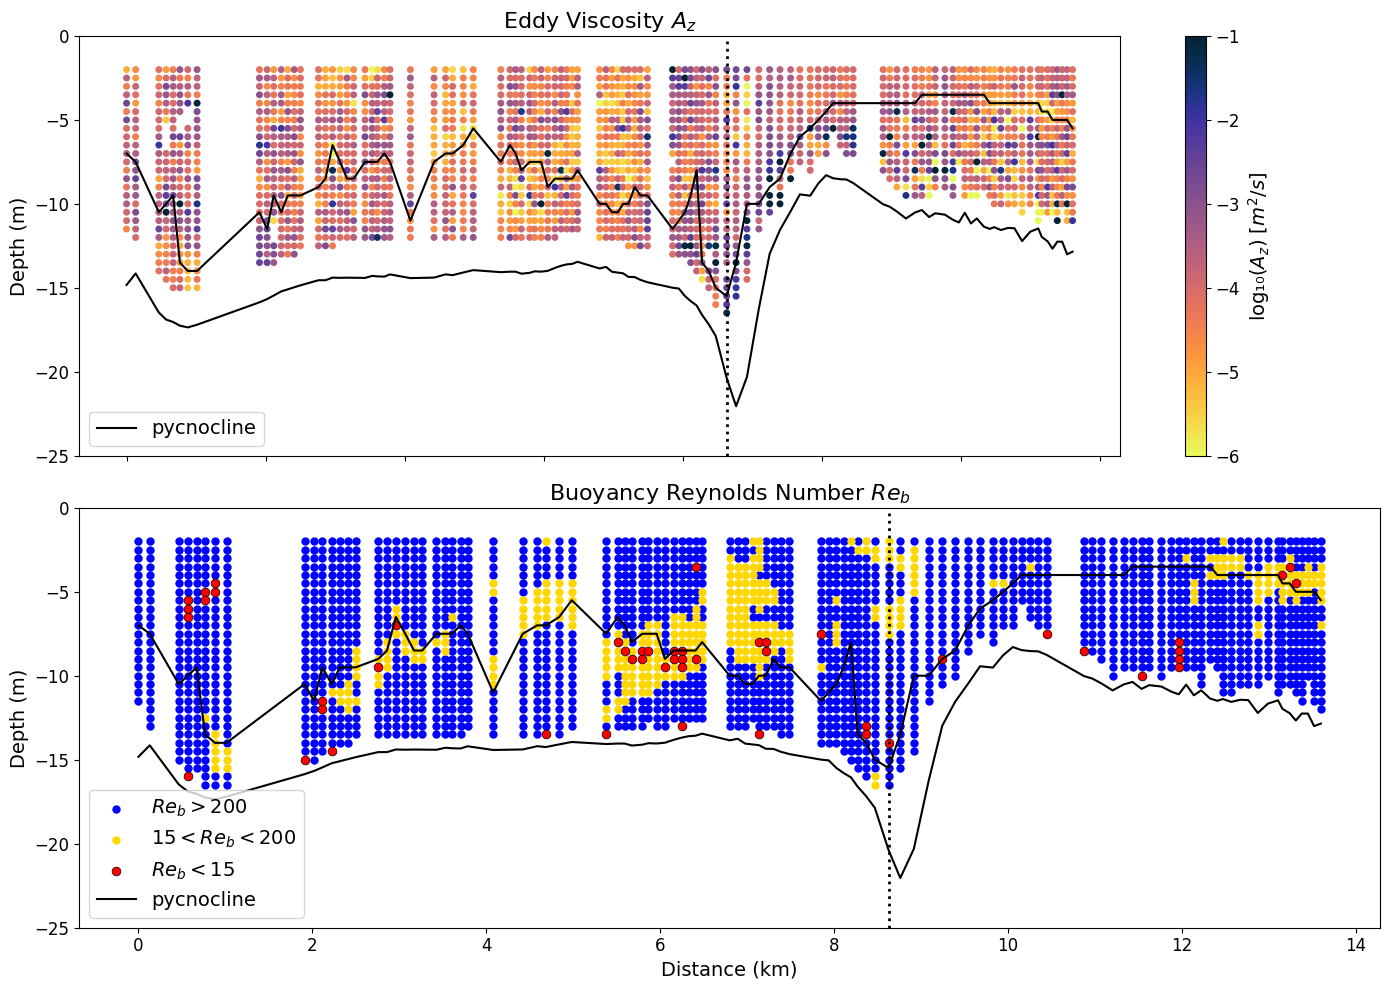

In [28]:
# --- CONFIGURAÇÕES VISUAIS GLOBAIS (Padrão) ---

# Configuração da Faixa de Profundidade (Eixo Y)
y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)

# Tamanhos de Fonte
fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 

# Tamanhos de Marcadores
dot_size_data_Az = 16
dot_size_data_Reb_base = 25

#====================================================
# --- AJUSTES DA COLORBAR DO Az ---
az_vmin = -6.0 
az_vmax = -1.0 
norm_az = mcolors.Normalize(vmin=az_vmin, vmax=az_vmax)
#====================================================

# --- CRIAÇÃO DA FIGURA ---
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)


#================================================
# 🎯 PLOT 1: Vertical Eddy Viscosity (Az)
#================================================

cb1 = axs[0].scatter(
    x_calc, -z_calc,
    s=dot_size_data_Az,
    c=np.log10(Az),
    cmap=cmocean.cm.thermal_r,
    norm=norm_az
)

axs[0].plot(dist_pic_Fr, -pic,
            color='k', linestyle='-', linewidth=1.5,
            label='pycnocline')

plot_sets(axs[0])

axs[0].set_title('Eddy Viscosity $A_z$', fontsize=fontsize_title)
axs[0].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[0].legend(fontsize=fontsize_main)

axs[0].tick_params(axis='both', which='major', labelsize=fontsize_ticks)
axs[0].tick_params(labelbottom=False)

cbar1 = fig.colorbar(cb1, ax=axs[0])
cbar1.set_label('log₁₀($A_z$) [$m^2/s$]', fontsize=fontsize_main)
cbar1.ax.tick_params(labelsize=fontsize_ticks)


#================================================
# 🎯 PLOT 2: Buoyancy Reynolds Number (Reb)
#================================================

# --- Definição das categorias ---
idx_very_low = (Reb < 15)
idx_intermediate = (Reb >= 15) & (Reb <= 200)
idx_high = (Reb > 200)

# 🔵 Reb > 200
axs[1].scatter(
    x_calc[idx_high], -z_calc[idx_high],
    s=25, marker='o',
    color='blue',
    label=r'$Re_b > 200$'
)

# 🔴 15 < Reb < 200
axs[1].scatter(
    x_calc[idx_intermediate], -z_calc[idx_intermediate],
    s=25, marker='o',
    color='gold',
    label=r'$15 < Re_b < 200$'
)

# 🟡 Reb < 15
axs[1].scatter(
    x_calc[idx_very_low], -z_calc[idx_very_low],
    s=40, marker='o',
    color='red',
    edgecolor='k', linewidth=0.5,
    label=r'$Re_b < 15$'
)

# Picnoclina
axs[1].plot(
    dist_pic_Fr, -pic,
    color='k', linestyle='-',
    linewidth=1.5,
    label='pycnocline'
)

plot_sets(axs[1])

axs[1].set_title(r'Buoyancy Reynolds Number $Re_b$', fontsize=fontsize_title)
axs[1].set_ylabel('Depth (m)', fontsize=fontsize_main)
axs[1].set_xlabel('Distance (km)', fontsize=fontsize_main)

axs[1].legend(loc='lower left', fontsize=fontsize_main)
axs[1].tick_params(axis='both', which='major', labelsize=fontsize_ticks)


#================================================
# 🎯 AJUSTE FINAL DOS EIXOS
#================================================

for ax in axs:
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='y', which='major', labelsize=fontsize_ticks)

axs[0].set_xlabel('')

plt.tight_layout()
# plt.savefig("AzXReb3_FINAL_PADRONIZADO.png", dpi=300)
plt.show()

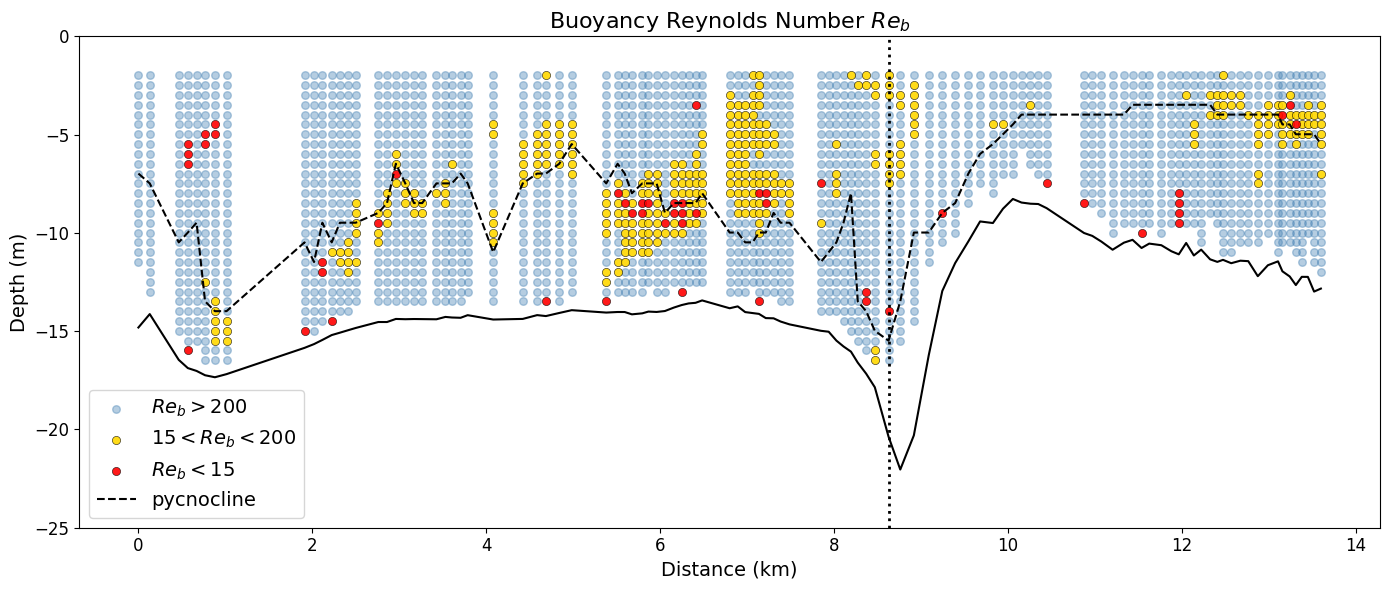

In [35]:
# --- CONFIGURAÇÕES VISUAIS ---

y_min = -25
y_max = 0
intervalo = 5
y_ticks = np.arange(y_min, y_max + intervalo, intervalo)

fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 

dot_size = 30


#================================================
# 🎯 FIGURA ÚNICA – Buoyancy Reynolds Number (Reb)
#================================================

fig, ax = plt.subplots(figsize=(14, 6))


# --- Definição das categorias ---
idx_very_low = (Reb < 15)
idx_intermediate = (Reb >= 15) & (Reb <= 200)
idx_high = (Reb > 200)


# 🔵 Reb > 200  (azul discreto)
ax.scatter(
    x_calc[idx_high], -z_calc[idx_high],
    s=dot_size,
    color='steelblue',
    alpha=0.4, #transparency
    label=r'$Re_b > 200$'
)

# 🟡 15 < Reb < 200 (mostarda suave)
ax.scatter(
    x_calc[idx_intermediate], -z_calc[idx_intermediate],
    s=dot_size+5,
    color='gold', #'goldenrod'for a smooth yellow
    edgecolor='k',
    linewidth=0.4,
    alpha=0.9,
    label=r'$15 < Re_b < 200$'
)

# 🔴 Reb < 15 (vermelho suave)
ax.scatter(
    x_calc[idx_very_low], -z_calc[idx_very_low],
    s=dot_size+5,
    color='red', # 'indianred' for a smooth red
    edgecolor='k',
    linewidth=0.4,
    alpha=0.9,
    label=r'$Re_b < 15$'
)


# --- Picnoclina ---
ax.plot(
    dist_pic_Fr, -pic,
    color='k',
    linestyle='--',
    linewidth=1.5,
    label='pycnocline'
)

plot_sets(ax)


# --- Labels ---
ax.set_title(r'Buoyancy Reynolds Number $Re_b$', fontsize=fontsize_title)
ax.set_ylabel('Depth (m)', fontsize=fontsize_main)
ax.set_xlabel('Distance (km)', fontsize=fontsize_main)

ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)

ax.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

ax.legend(loc='lower left', fontsize=fontsize_main, frameon=True)


plt.tight_layout()
# plt.savefig("Reb_only_clean.png", dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/2935028086.py:10: RuntimeWarning: invalid value encountered in log10
  c=np.log10(Az), cmap=cmocean.cm.thermal_r)
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_65561/2935028086.py:30: RuntimeWarning: invalid value encountered in log10
  log_Reb = np.log10(Reb)


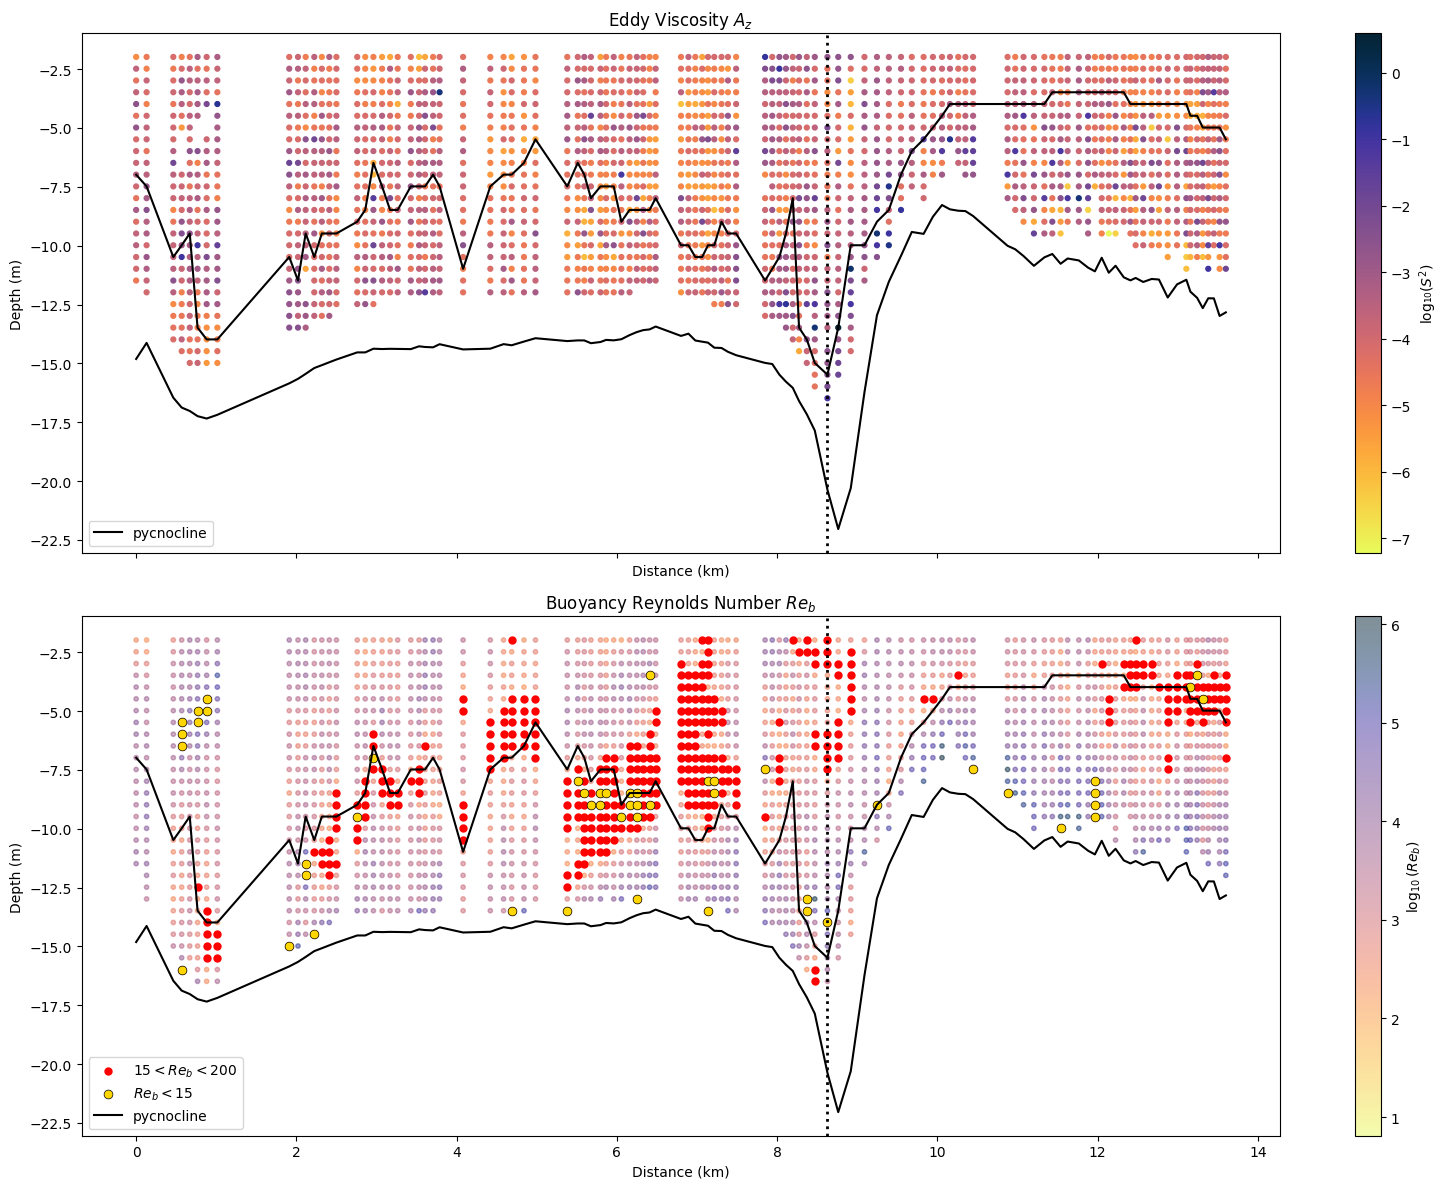

In [29]:
# --- Código para plotar as variaveis comparativamente:
fig, axs = plt.subplots(2, 1, figsize=(16, 12), sharex=True)


#================================================
#    PLOT 1: Vertical Eddy Viscosity (Az)
#================================================

cb = axs[0].scatter(x_calc, -z_calc, s=12,
                     c=np.log10(Az), cmap=cmocean.cm.thermal_r)
axs[0].plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,label='pycnocline') 
#axs[0].scatter(dist_pic_Fr, -pic, color='k', s=30, marker='o', label='pycnocline') # Adicionando os pontos da picnoclina aqui
plot_sets(axs[0])
axs[0].set_title('Eddy Viscosity $A_z$')
axs[0].set_ylabel('Depth (m)')
axs[0].legend()
fig.colorbar(cb, ax=axs[0], label='log₁₀($S^2$)')


#================================================
#    PLOT 2: buoyancy Reynold number (Reb)
#================================================

# === buoyancy Reynold number (Reb) ===
# --- Configuração de Limiares (Manter a mesma) ---
LOG_REB_200 = np.log10(200)
LOG_REB_15 = np.log10(15)

# --- Cálculo dos Índices de Filtragem (Manter o mesmo) ---
log_Reb = np.log10(Reb)
idx_low_turb = (Reb < 200)
idx_very_low_turb = (Reb < 15)


# === buoyancy Reynold number (Reb) ===
ax = axs[1]

# Passo 1: Plotar todos os pontos (Fundo) com OPACIDADE REDUZIDA (alpha=0.5) e s menor
cb = ax.scatter(x_calc, -z_calc, s=10, # Tamanho reduzido para 10
                 c=log_Reb, cmap=cmocean.cm.thermal_r,
                 alpha=0.5) # Opacidade reduzida para suavizar

# Passo 2: Plotar os pontos com Reb < 200 (Turbulência Fraca)
# Aumentamos o tamanho (s) para contraste
ax.scatter(x_calc[idx_low_turb], -z_calc[idx_low_turb],
           s=25, marker='o', color='red',
           label=r'$15 < Re_b < 200$')

# Passo 3: Plotar os pontos com Reb < 15 (Turbulência Mínima)
# Aumentamos o tamanho (s) para contraste máximo
ax.scatter(x_calc[idx_very_low_turb], -z_calc[idx_very_low_turb],
           s=40, marker='o', color='gold', edgecolor='k', linewidth=0.5,
           label=r'$Re_b < 15$')


# --- Nova Picnoclina Discreta (Linha Simples) ---
# Mudamos o scatter para plotar a linha da picnoclina:
ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,
        label='pycnocline') 
# Se você realmente quiser manter os marcadores PONTOS PRETOS discretos:
# ax.scatter(dist_pic_Fr, -pic, color='k', s=8, marker='.') 


# --- Configurações Finais ---
# Mantenha plot_sets, títulos e colorbar
plot_sets(ax)
ax.set_title(r'Buoyancy Reynolds Number $Re_b$')
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Distance (km)')
ax.legend(loc='lower left')
fig.colorbar(cb, ax=ax, label=r'$\log_{10}(Re_b)$')


plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/AzXReb3.png", dpi=300)
plt.show()

## Tentando calcular a média do epsilon acima e abaixo da picnoclina:

In [30]:
# --- Checagem de Tamanhos das Variáveis Originais ---

print("--- Tamanhos das Variáveis Originais (mtz_tj) ---")
print(f"idx (mtz_tj[:,0]) shape: {idx.shape}")
print(f"x (mtz_tj[:,1]) shape: {x.shape}")
print(f"z (mtz_tj[:,2]) shape: {z.shape}")
print(f"rho (mtz_tj[:,5]) shape: {rho.shape}")

print("\n--- Tamanhos das Variáveis Calculadas (mtz_tj_calc) ---")
print(f"x_calc (mtz_tj_calc[:,0]) shape: {x_calc.shape}")
print(f"z_calc (mtz_tj_calc[:,1]) shape: {z_calc.shape}")
print(f"Epsilon (mtz_tj_calc[:,5]) shape: {Epsilon.shape}")
print(f"Az (mtz_tj_calc[:,6]) shape: {Az.shape}")

# O problema de desalinhamento ocorre quando a matriz de onde Az e Epsilon 
# vieram (mtz_tj_calc) tem um número diferente de linhas da matriz de onde idx, x, z 
# vieram (mtz_tj).

# Você pode rodar este código e me dizer os resultados, ou eu posso tentar 
# consertar o alinhamento com base na suposição mais provável.

--- Tamanhos das Variáveis Originais (mtz_tj) ---
idx (mtz_tj[:,0]) shape: (2386,)
x (mtz_tj[:,1]) shape: (2386,)
z (mtz_tj[:,2]) shape: (2386,)
rho (mtz_tj[:,5]) shape: (2386,)

--- Tamanhos das Variáveis Calculadas (mtz_tj_calc) ---
x_calc (mtz_tj_calc[:,0]) shape: (2279,)
z_calc (mtz_tj_calc[:,1]) shape: (2279,)
Epsilon (mtz_tj_calc[:,5]) shape: (2279,)
Az (mtz_tj_calc[:,6]) shape: (2279,)


In [31]:
# =================================================================
# CÁLCULO 1: MÉDIAS SUPERIOR E INFERIOR + média total por perfil
# =================================================================

# --- 1. Alinhamento e Interpolação da Picnoclina ---

# Usaremos os arrays Epsilon, z_calc, x_calc (L_calc = 2279)
# A picnoclina precisa ser interpolada para CADA ponto de x_calc
pic_interp = np.interp(x_calc, dist_pic_Fr, pic)
L_calc = len(Epsilon)

# --- 2. Definição da Grade (Grid) ---

unique_x = np.unique(x_calc)
num_profiles = len(unique_x)
Z_start = np.min(z_calc) 
Z_end = np.max(z_calc)
Z_resolution = 0.5 
Z_grid = np.arange(Z_start, Z_end + Z_resolution, Z_resolution)
num_depths = len(Z_grid)

# Inicializar as Matrizes Finais (Gridadas) com NaN
Eps_Superior_Grid = np.full((num_depths, num_profiles), np.nan)
Eps_Inferior_Grid = np.full((num_depths, num_profiles), np.nan)
# *** NOVO: Matriz para o Epsilon TOTAL ***
Eps_Total_Grid = np.full((num_depths, num_profiles), np.nan) # Para Epsilon de toda a coluna

# --- 3. Loop de Gridagem e Corte por Perfil (x_calc) ---

for col_idx, x_coord in enumerate(unique_x):
    
    mask_perfil = (x_calc == x_coord)
    z_perfil = z_calc[mask_perfil]
    epsilon_perfil = Epsilon[mask_perfil] # Usando Epsilon não suavizado
    pic_depth_limite = np.mean(pic_interp[mask_perfil])

    for row_idx, z_ref in enumerate(Z_grid):
        
        # Encontre o ponto de Epsilon mais próximo à profundidade de referência (z_ref)
        z_diff = np.abs(z_perfil - z_ref)
        min_idx = np.argmin(z_diff)
        eps_value = epsilon_perfil[min_idx]
        
        # 3e. Armazenar o valor de Epsilon na Grade Total
        Eps_Total_Grid[row_idx, col_idx] = eps_value 
        
        # 3f. Lógica de Corte para Superior/Inferior (Seu Código Original)
        if z_ref < pic_depth_limite:
            Eps_Superior_Grid[row_idx, col_idx] = eps_value
            Eps_Inferior_Grid[row_idx, col_idx] = np.nan
        
        elif z_ref >= pic_depth_limite:
            Eps_Inferior_Grid[row_idx, col_idx] = eps_value
            Eps_Superior_Grid[row_idx, col_idx] = np.nan
            
# --- 4. Cálculo das Médias Finais por Perfil ---

# Médias Superior e Inferior (Original)
Epsuperior = np.nanmean(Eps_Superior_Grid, axis=0) 
Epinferior = np.nanmean(Eps_Inferior_Grid, axis=0)
x_perfil_coords = unique_x # As coordenadas X dos perfis

# *** NOVO: Cálculo do Epsilon Médio Total ***
# A média da coluna ignora NaNs onde não há dados de perfil na grade Z.
Epsmean_total = np.nanmean(Eps_Total_Grid, axis=0) 
# Esta variável é o Epsilon médio por perfil na coluna total.

In [32]:
len(Epsmean_total)

107

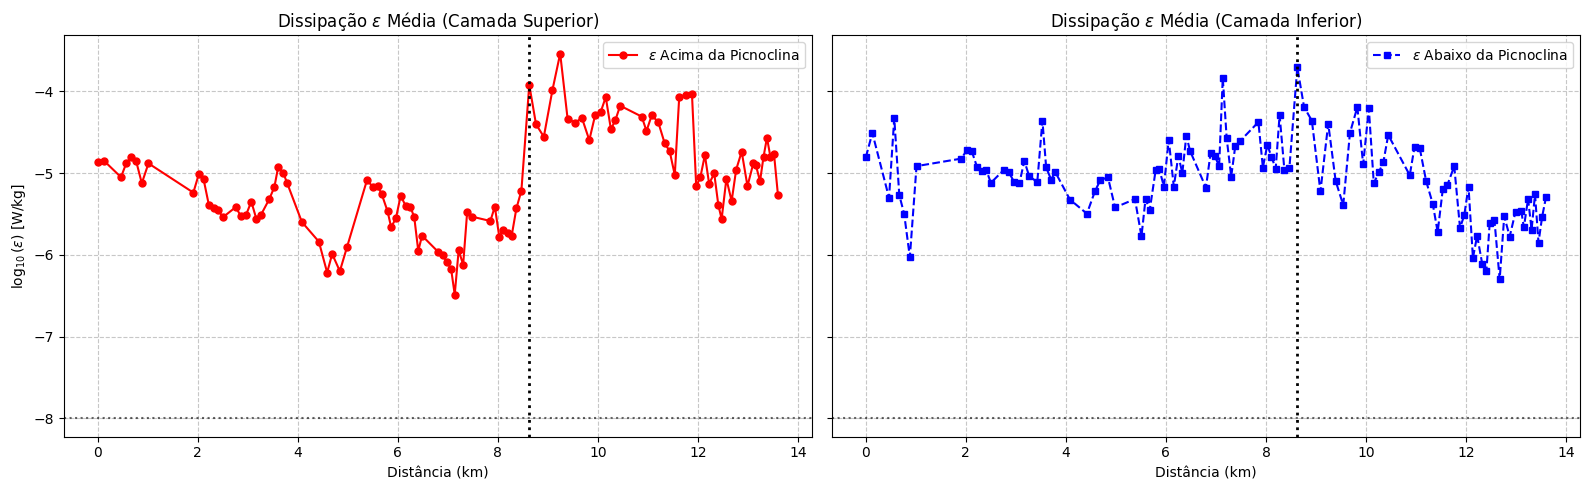

In [33]:
# --- 1. Preparação dos Dados para Plotagem ---
# Assumimos que as variáveis Epsuperior, Epinferior e x_perfil_coords
# foram criadas com sucesso na etapa anterior.

# Calculando o logaritmo dos valores (essencial para Epsilon)
log_Epsuperior = np.log10(Epsuperior)
log_Epinferior = np.log10(Epinferior)

# Valor de referência X para a linha vertical
x_ref = dist_batimetria[62]

# --- 2. Criação dos Subplots (Um ao lado do outro) ---
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True) # sharey=True para manter a mesma escala vertical

# --- Subplot 1: Camada Superior (Upper Layer) ---
ax1 = axs[0]
ax1.plot(x_perfil_coords, log_Epsuperior, 
         marker='o', linestyle='-', color='red', linewidth=1.5, markersize=5, 
         label=r'$\epsilon$ Acima da Picnoclina')

ax1.set_title(r'Dissipação $\epsilon$ Média (Camada Superior)')
ax1.set_xlabel('Distância (km)')
ax1.set_ylabel(r'$\log_{10}(\epsilon)$ [W/kg]')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Linhas de Referência
ax1.axhline(-8, color='k', linestyle=':', alpha=0.6) # Linha Horizontal
ax1.axvline(x_ref, color='k', ls=':', lw=2, label=f'Ref. em {x_ref:.2f} km') # Linha Vertical

# --- Subplot 2: Camada Inferior (Bottom Layer) ---
ax2 = axs[1]
ax2.plot(x_perfil_coords, log_Epinferior, 
         marker='s', linestyle='--', color='blue', linewidth=1.5, markersize=5,
         label=r'$\epsilon$ Abaixo da Picnoclina')

ax2.set_title(r'Dissipação $\epsilon$ Média (Camada Inferior)')
ax2.set_xlabel('Distância (km)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# Linhas de Referência
ax2.axhline(-8, color='k', linestyle=':', alpha=0.6) # Linha Horizontal
ax2.axvline(x_ref, color='k', ls=':', lw=2) # Linha Vertical (Sem label para evitar repetição na legenda)

# Ajuste Final
plt.tight_layout()
plt.show()

In [34]:
###### TESTEEEEEE

# =================================================================
# BLOCO 1: CÁLCULO E AGREGAÇÃO (INCORPORANDO MÉDIA TOTAL)
# =================================================================

# --- Replicando o Cálculo (Para garantir que as variáveis sejam definidas) ---
L_CALC = len(Epsilon)
idx_alinhado = idx[:L_CALC]

# Epsilon Suavizado (L-1 pontos)
Epsilon_smooth = (Epsilon[1:] + Epsilon[:-1]) / 2

# Alinhar todos os outros arrays para o novo comprimento (L-1)
idx_smooth = idx_alinhado[:-1] 
z_smooth = z_calc[:-1]
x_smooth = x_calc[:-1]

# Alinhar a Profundidade da Picnoclina por Interpolação (L-1)
pic_interp = np.interp(x_smooth, dist_pic_Fr, pic)

# Estrutura de Saída e Loop
unique_profiles = np.unique(idx_smooth)
num_profiles = len(unique_profiles)
# Aumentamos o array de resultados para 4 colunas: [x_medio, Epsuperior, Epinferior, Epsmean_total]
Epsilon_results = np.full((num_profiles, 4), np.nan) 

for i, p_idx in enumerate(unique_profiles):
    mask_perfil = (idx_smooth == p_idx)
    z_perfil = z_smooth[mask_perfil]
    epsilon_perfil = Epsilon_smooth[mask_perfil] # Epsilon para o perfil
    
    # Corte da Picnoclina
    pic_perfil = pic_interp[mask_perfil]
    pic_depth_limite = np.mean(pic_perfil) 
    
    mask_superior = (z_perfil < pic_depth_limite)
    eps_superior = epsilon_perfil[mask_superior]
    mask_inferior = (z_perfil > pic_depth_limite)
    eps_inferior = epsilon_perfil[mask_inferior]
    
    # --- NOVO CÁLCULO: Epsilon Médio Total (de todo o perfil) ---
    eps_mean_total = np.nanmean(epsilon_perfil) 

    x_coords_perfil = x_smooth[mask_perfil]
    Epsilon_results[i, 0] = np.mean(x_coords_perfil) # x_medio_perfil
    
    if len(eps_superior) > 0:
        Epsilon_results[i, 1] = np.nanmean(eps_superior) # Epsuperior
    
    if len(eps_inferior) > 0:
        Epsilon_results[i, 2] = np.nanmean(eps_inferior) # Epinferior

    Epsilon_results[i, 3] = eps_mean_total # Epsmean_total

# Extração Final (Define as variáveis que você precisa)
x_medio_perfil = Epsilon_results[:, 0]
Epsuperior = Epsilon_results[:, 1]
Epinferior = Epsilon_results[:, 2]
Epsmean_total = Epsilon_results[:, 3] # <--- VARIÁVEL TOTAL ALINHADA!


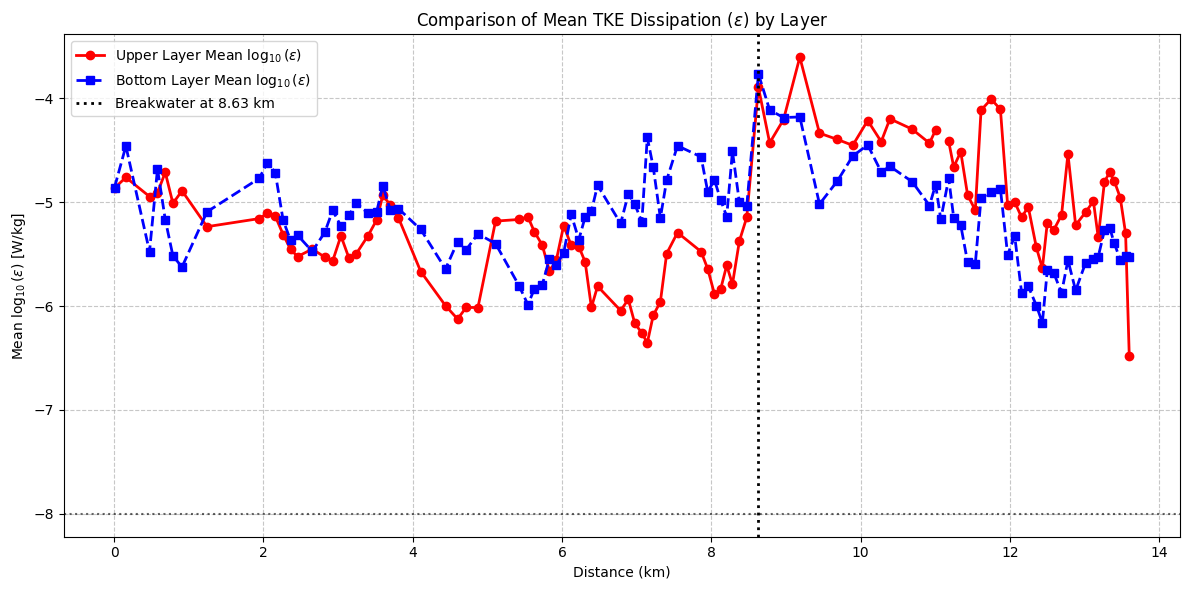

In [35]:
# =================================================================
# BLOCO 2: PLOTAGEM (Gráfico Único, em Inglês)
# =================================================================

# Preparação dos Dados para Plotagem
log_Epsuperior = np.log10(Epsuperior)
log_Epinferior = np.log10(Epinferior)
x_ref = dist_batimetria[62] 

# Criação do Gráfico Único
fig, ax = plt.subplots(figsize=(12, 6))

# Plotagem da Camada Superior (Upper Layer)
ax.plot(x_medio_perfil, log_Epsuperior, 
        marker='o', linestyle='-', color='red', linewidth=2, markersize=6, 
        label=r'Upper Layer Mean $\log_{10}(\epsilon)$')

# Plotagem da Camada Inferior (Bottom Layer)
ax.plot(x_medio_perfil, log_Epinferior, 
        marker='s', linestyle='--', color='blue', linewidth=2, markersize=6,
        label=r'Bottom Layer Mean $\log_{10}(\epsilon)$')

# --- Linhas de Referência ---

# Linha Horizontal (Ex: -8 W/kg, valor comum)
ax.axhline(-8, color='k', linestyle=':', alpha=0.6) 

# Linha Vertical (Referência de Batimetria)
ax.axvline(x_ref, color='k', ls=':', lw=2, 
           label=f'Breakwater at {x_ref:.2f} km') 

# --- Títulos e Legendas (Tudo em Inglês) ---

ax.set_title(r'Comparison of Mean TKE Dissipation ($\epsilon$) by Layer')
ax.set_xlabel('Distance (km)')
ax.set_ylabel(r'Mean $\log_{10}(\epsilon)$ [W/kg]')

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='best') 

plt.tight_layout()
plt.show()

### Tentando sincronizar as variaveis com a area das secoes transversais ao longo do canal interno:

In [36]:
#========================================================
# abrindo as areas das secoes transversais sincronizadas:
#========================================================


with open(path + 'areas_secoes_sincronizadas.pkl', 'rb') as io:
    areas = pickle.load(io)


In [37]:
len (dist_batimetria)

107

In [38]:
len (Epsuperior)

102

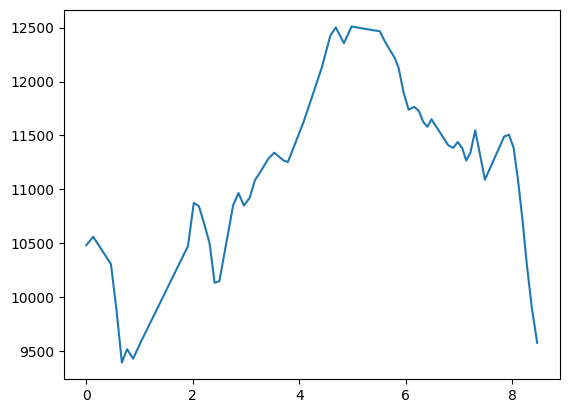

In [39]:
plt.plot(dist_batimetria, areas)

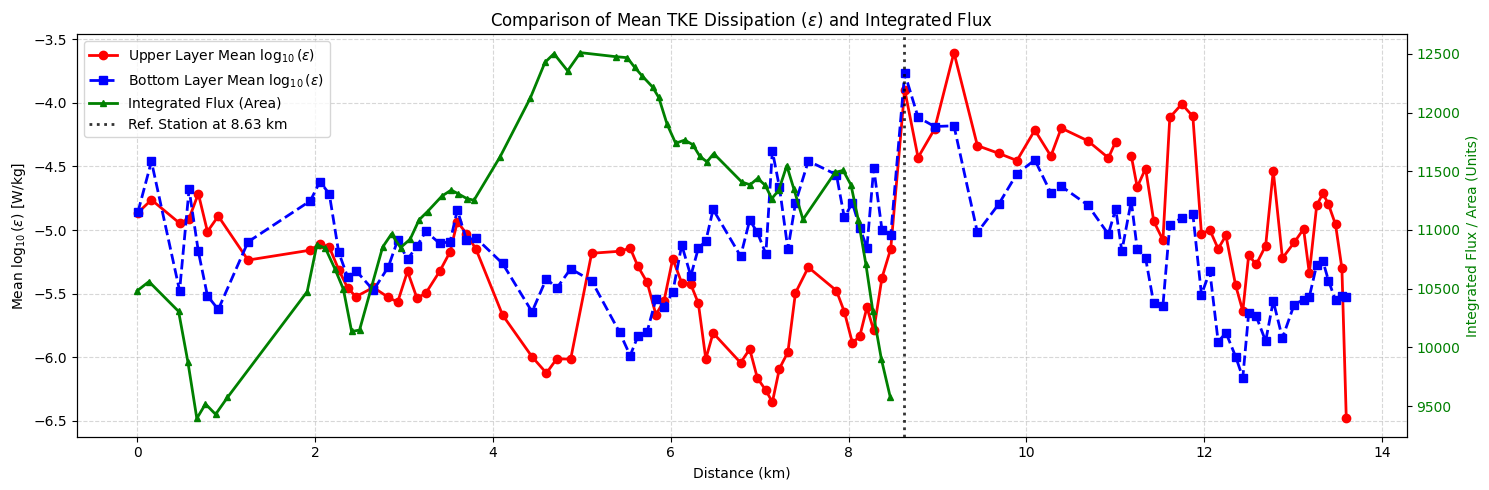

In [40]:
# --- 1. Preparação dos Dados (Assumindo que o Bloco 1 foi executado e definiu as variáveis) ---

# Preparações necessárias para a plotagem
log_Epsuperior = np.log10(Epsuperior)
log_Epinferior = np.log10(Epinferior)
x_ref = dist_batimetria[62] 

# --- SIMULAÇÃO DA VARIÁVEL 'areas' ---
# *** ESSA SIMULAÇÃO DEVE SER REMOVIDA NO SEU CÓDIGO FINAL ***
# A variável 'areas' JÁ ESTÁ DEFINIDA NO SEU NOTEBOOK.
# Usamos esta simulação APENAS para garantir que o código rode aqui.
#areas = np.random.rand(len(dist_batimetria)) * 5e-7 + 1e-6 
#log_areas = np.log10(areas) # Vamos plotar log(areas) se for um fluxo

# --- 2. Criação do Gráfico Único com EIXO Y DUPLO ---

fig, ax1 = plt.subplots(figsize=(15, 5))

# --- EIXO Y ESQUERDO (ax1): Dissipação Epsilon (Principal) ---

# Plotagem da Camada Superior (Upper Layer)
line1 = ax1.plot(x_medio_perfil, log_Epsuperior, 
                 marker='o', linestyle='-', color='red', linewidth=2, markersize=6, 
                 label=r'Upper Layer Mean $\log_{10}(\epsilon)$')

# Plotagem da Camada Inferior (Bottom Layer)
line2 = ax1.plot(x_medio_perfil, log_Epinferior, 
                 marker='s', linestyle='--', color='blue', linewidth=2, markersize=6,
                 label=r'Bottom Layer Mean $\log_{10}(\epsilon)$')

# Configurações do Eixo 1
ax1.set_title(r'Comparison of Mean TKE Dissipation ($\epsilon$) and Integrated Flux')
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel(r'Mean $\log_{10}(\epsilon)$ [W/kg]', color='k') # Eixo Principal em Log(Epsilon)
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- EIXO Y DIREITO (ax2): Variável 'areas' ---

ax2 = ax1.twinx()  # Cria um segundo eixo Y que compartilha o mesmo eixo X
ax2.set_ylabel('Integrated Flux / Area (Units)', color='green') 
ax2.tick_params(axis='y', labelcolor='green')

# Plotagem da Variável 'areas' (Usando dist_batimetria)
line3 = ax2.plot(dist_batimetria, areas, 
                 marker='^', linestyle='-', color='green', linewidth=2, markersize=5,
                 label='Integrated Flux (Area)') # Mantenha o label em Inglês

# --- Linhas de Referência (Aplicadas ao Eixo X compartilhado) ---

# Linha Vertical (Referência de Batimetria)
ax1.axvline(x_ref, color='k', ls=':', lw=2, alpha=0.8,
           label=f'Ref. Station at {x_ref:.2f} km') 

# --- Combinação das Legendas ---

# Junta todas as linhas (dos dois eixos) e as legendas correspondentes
lines = line1 + line2 + ax2.get_lines() + ax1.get_lines()[-1:] # Inclui a axvline
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best', fontsize=10)


plt.tight_layout()
plt.show()

#### incluindo a linha vertical da ponta dos pescadores: 

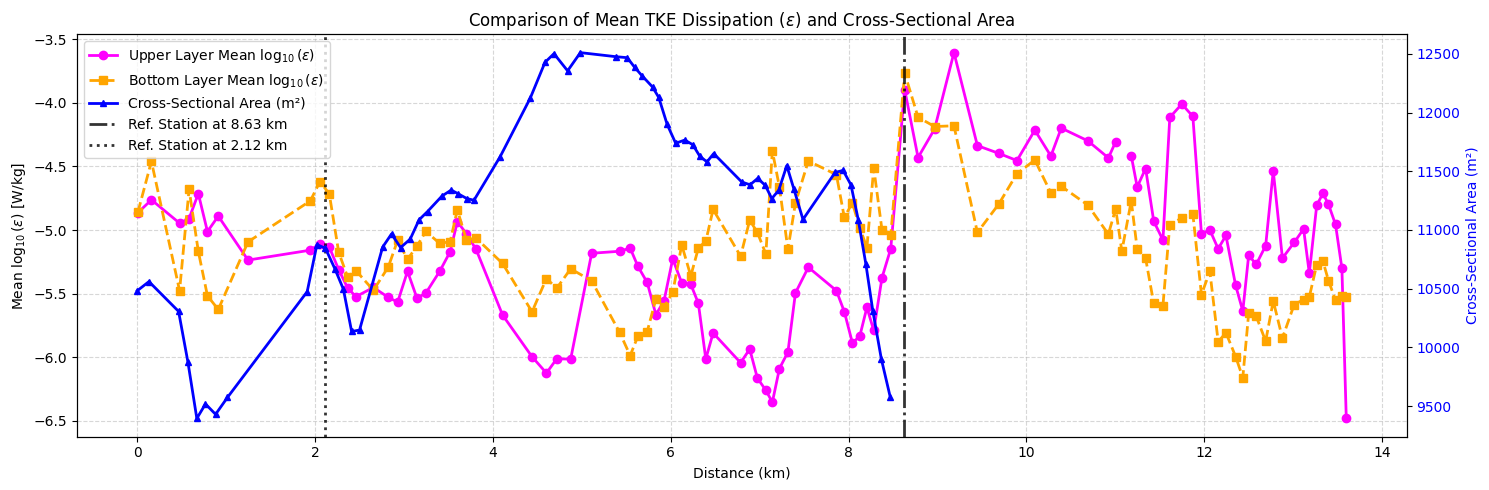

In [41]:
# --- 1. Preparação dos Dados (Assumindo que o Bloco 1 foi executado e definiu as variáveis) ---

# Preparações necessárias para a plotagem
log_Epsuperior = np.log10(Epsuperior)
log_Epinferior = np.log10(Epinferior)
x_ref1 = dist_batimetria[10] 
x_ref2 = dist_batimetria[62] 

# --- SIMULAÇÃO DA VARIÁVEL 'areas' ---
# *** ESSA SIMULAÇÃO DEVE SER REMOVIDA NO SEU CÓDIGO FINAL ***
# A variável 'areas' JÁ ESTÁ DEFINIDA NO SEU NOTEBOOK.
# Usamos esta simulação APENAS para garantir que o código rode aqui.
#areas = np.random.rand(len(dist_batimetria)) * 5e-7 + 1e-6 
#log_areas = np.log10(areas) # Vamos plotar log(areas) se for um fluxo

# --- 2. Criação do Gráfico Único com EIXO Y DUPLO ---

fig, ax1 = plt.subplots(figsize=(15, 5))

# --- EIXO Y ESQUERDO (ax1): Dissipação Epsilon (Principal) ---

# Plotagem da Camada Superior (Upper Layer)
line1 = ax1.plot(x_medio_perfil, log_Epsuperior, 
                 marker='o', linestyle='-', color='magenta', linewidth=2, markersize=6, 
                 label=r'Upper Layer Mean $\log_{10}(\epsilon)$')

# Plotagem da Camada Inferior (Bottom Layer)
line2 = ax1.plot(x_medio_perfil, log_Epinferior, 
                 marker='s', linestyle='--', color='orange', linewidth=2, markersize=6,
                 label=r'Bottom Layer Mean $\log_{10}(\epsilon)$')

# Configurações do Eixo 1
ax1.set_title(r'Comparison of Mean TKE Dissipation ($\epsilon$) and Cross-Sectional Area')
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel(r'Mean $\log_{10}(\epsilon)$ [W/kg]', color='k') # Eixo Principal em Log(Epsilon)
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- EIXO Y DIREITO (ax2): Variável 'areas' ---

ax2 = ax1.twinx()  # Cria um segundo eixo Y que compartilha o mesmo eixo X
ax2.set_ylabel('Cross-Sectional Area (m²)', color='blue') 
ax2.tick_params(axis='y', labelcolor='blue')

# Plotagem da Variável 'areas' (Usando dist_batimetria)
line3 = ax2.plot(dist_batimetria, areas, 
                 marker='^', linestyle='-', color='blue', linewidth=2, markersize=5,
                 label='Cross-Sectional Area (m²)') # Mantenha o label em Inglês

# --- Linhas de Referência (Aplicadas ao Eixo X compartilhado) ---

# Linha Vertical (Referência de Batimetria)
ax1.axvline(x_ref1, color='k', ls=':', lw=2, alpha=0.8,
           label=f'Ref. Station at {x_ref1:.2f} km') 

ax2.axvline(x_ref2, color='k', ls='-.', lw=2, alpha=0.8,
           label=f'Ref. Station at {x_ref2:.2f} km')


# --- Combinação das Legendas ---

# Junta todas as linhas (dos dois eixos) e as legendas correspondentes
lines = line1 + line2 + ax2.get_lines() + ax1.get_lines()[-1:] # Inclui a axvline
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best', fontsize=10)


plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/EpsilonXarea.png", dpi=300)
plt.show()

## Epsilon médio x area

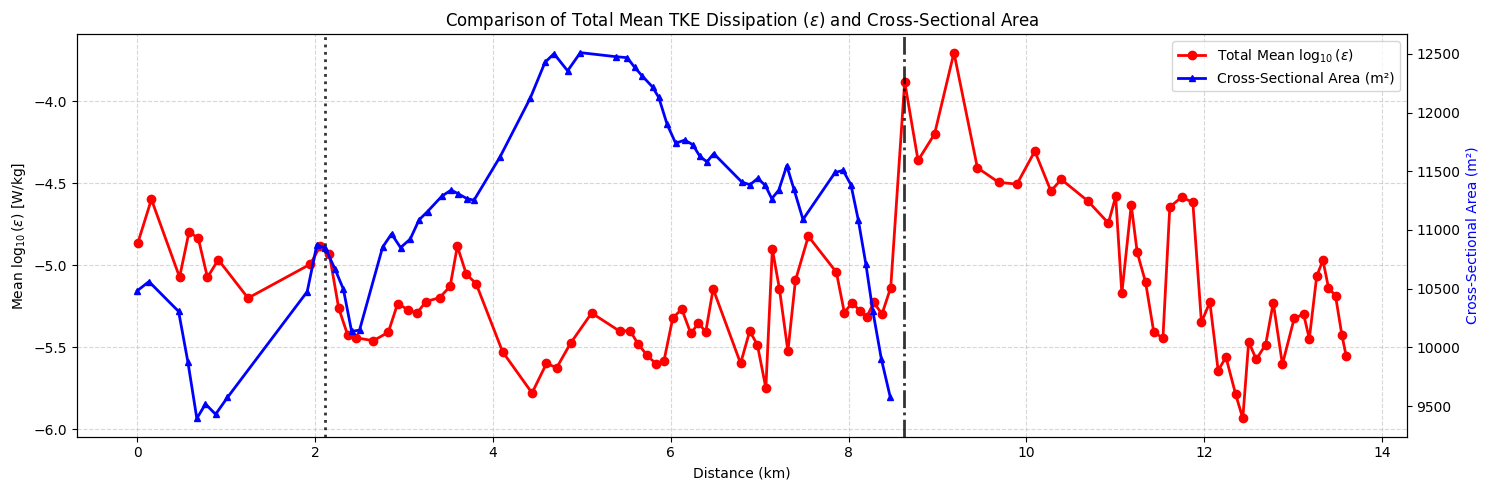

In [42]:
# =================================================================
# BLOCO 2: PLOTAGEM (CORREÇÃO FINAL DA LEGENDA)
# =================================================================

# Preparação das variáveis de plotagem
log_Epsmean_total = np.log10(Epsmean_total) 
log_Epinferior = np.log10(Epinferior)

# Variáveis de Referência
x_ref1 = dist_batimetria[10] 
x_ref2 = dist_batimetria[62] 


fig, ax1 = plt.subplots(figsize=(15, 5))

# --- EIXO Y ESQUERDO (ax1): Dissipação Epsilon (Principal) ---
line1 = ax1.plot(x_medio_perfil, log_Epsmean_total, 
                 marker='o', linestyle='-', color='red', linewidth=2, markersize=6, 
                 label=r'Total Mean $\log_{10}(\epsilon)$') 

#line2 = ax1.plot(x_medio_perfil, log_Epinferior, 
                 #marker='s', linestyle='--', color='blue', linewidth=2, markersize=6,
                 #label=r'Bottom Layer Mean $\log_{10}(\epsilon)$')

# Configurações do Eixo 1
ax1.set_title(r'Comparison of Total Mean TKE Dissipation ($\epsilon$) and Cross-Sectional Area')
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel(r'Mean $\log_{10}(\epsilon)$ [W/kg]', color='k')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- EIXO Y DIREITO (ax2): Variável 'areas' ---
ax2 = ax1.twinx()
ax2.set_ylabel('Cross-Sectional Area (m²)', color='blue')
line3 = ax2.plot(dist_batimetria, areas,
                 marker='^', linestyle='-', color='blue', linewidth=2, markersize=5,
                 label='Cross-Sectional Area (m²)')

# --- Linhas de Referência ---
line_v1 = ax1.axvline(x_ref1, color='k', ls=':', lw=2, alpha=0.8) 
line_v2 = ax1.axvline(x_ref2, color='k', ls='-.', lw=2, alpha=0.8)


# --- Combinação das Legendas CORRIGIDA ---

# line1 e line2 JÁ SÃO LISTAS. Apenas concatenamos TUDO como listas simples.
# Usamos list() para garantir que ax2.get_lines() seja um objeto concatenável.
lines_plot = line1 + list(ax2.get_lines())

# Extrair os rótulos
labels_plot = [l.get_label() for l in lines_plot]

# Criar a legenda (ignora as axvline, como desejado)
ax1.legend(lines_plot, labels_plot, loc='best', fontsize=10)

plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/EpsilonmeanXarea.png", dpi=300)
plt.show()

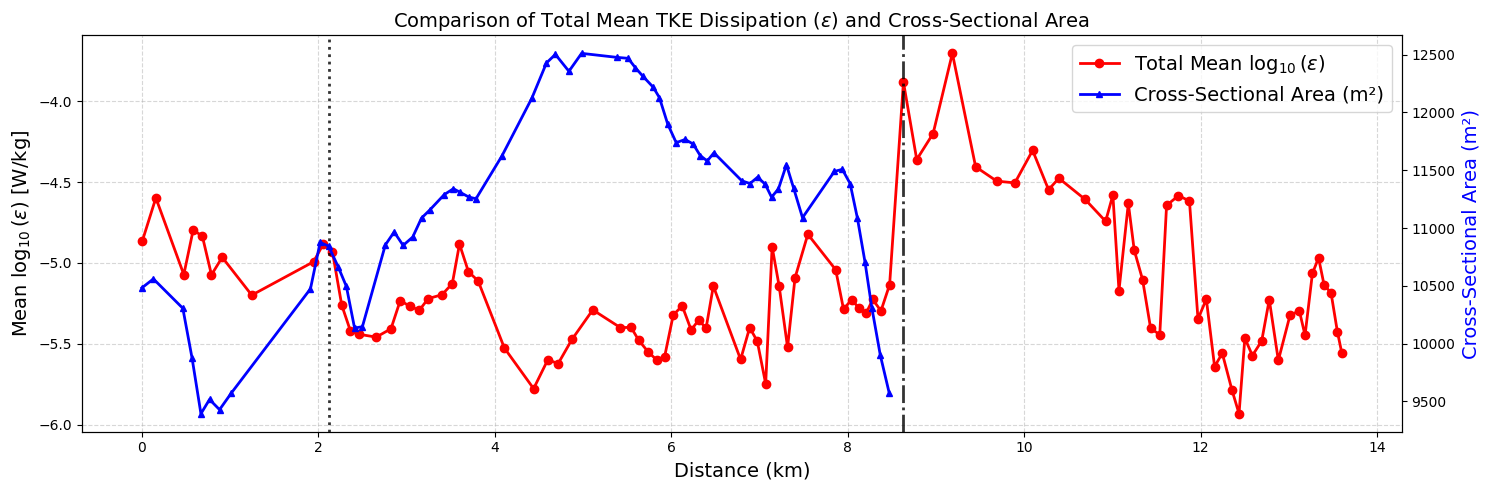

In [47]:
# =================================================================
# BLOCO 2: PLOTAGEM (CORREÇÃO FINAL DA LEGENDA)
# =================================================================
# --- CONFIGURAÇÕES VISUAIS GLOBAIS (Padrão) ---

# Tamanhos de Fonte
fontsize_main = 14
fontsize_title = 16 
fontsize_ticks = 12 

# Preparação das variáveis de plotagem
log_Epsmean_total = np.log10(Epsmean_total) 
log_Epinferior = np.log10(Epinferior)

# Variáveis de Referência
x_ref1 = dist_batimetria[10] 
x_ref2 = dist_batimetria[62] 


fig, ax1 = plt.subplots(figsize=(15, 5))

# --- EIXO Y ESQUERDO (ax1): Dissipação Epsilon (Principal) ---
line1 = ax1.plot(x_medio_perfil, log_Epsmean_total, 
                 marker='o', linestyle='-', color='red', linewidth=2, markersize=6, 
                 label=r'Total Mean $\log_{10}(\epsilon)$') 

#line2 = ax1.plot(x_medio_perfil, log_Epinferior, 
                 #marker='s', linestyle='--', color='blue', linewidth=2, markersize=6,
                 #label=r'Bottom Layer Mean $\log_{10}(\epsilon)$')

# Configurações do Eixo 1
ax1.set_title(r'Comparison of Total Mean TKE Dissipation ($\epsilon$) and Cross-Sectional Area', fontsize = 14)
ax1.set_xlabel('Distance (km)', fontsize = 14)
ax1.set_ylabel(r'Mean $\log_{10}(\epsilon)$ [W/kg]', color='k', fontsize = 14)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- EIXO Y DIREITO (ax2): Variável 'areas' ---
ax2 = ax1.twinx()
ax2.set_ylabel('Cross-Sectional Area (m²)', fontsize = 14, color='blue')
line3 = ax2.plot(dist_batimetria, areas,
                 marker='^', linestyle='-', color='blue', linewidth=2, markersize=5,
                 label='Cross-Sectional Area (m²)')

# --- Linhas de Referência ---
line_v1 = ax1.axvline(x_ref1, color='k', ls=':', lw=2, alpha=0.8) 
line_v2 = ax1.axvline(x_ref2, color='k', ls='-.', lw=2, alpha=0.8)


# --- Combinação das Legendas CORRIGIDA ---

# line1 e line2 JÁ SÃO LISTAS. Apenas concatenamos TUDO como listas simples.
# Usamos list() para garantir que ax2.get_lines() seja um objeto concatenável.
lines_plot = line1 + list(ax2.get_lines())

# Extrair os rótulos
labels_plot = [l.get_label() for l in lines_plot]

# Criar a legenda (ignora as axvline, como desejado)
ax1.legend(lines_plot, labels_plot, loc='best', fontsize=14)

plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/EpsilonmeanXarea2.png", dpi=300)
plt.show()

## Fazendo o mesmo para Az

In [28]:
# =================================================================
# BLOCO 1: CÁLCULO DA MÉDIA DE AZ POR PERFIL (SEM TRATAMENTO DE VALORES NULOS PARA PLOTAGEM)
# =================================================================

# Assumimos que 'Az' e 'x_calc' já estão definidos no seu ambiente.
# Exemplo de simulação (remova no seu código real):
# L_CALC = 2279
# np.random.seed(42)
# Az = np.abs(np.random.randn(L_CALC) * 1e-4) # Valores positivos
# x_calc = np.linspace(0, 14, L_CALC)
# dist_batimetria = np.linspace(0, 8.63, 63) # Para o limite da área

Az_orig = Az 
x_calc_orig = x_calc

# 1. Identificar perfis únicos de Az
unique_x_az = np.unique(x_calc_orig) 
num_profiles_az = len(unique_x_az)

# 2. Calcular o Az Médio por Perfil
Az_mean_by_profile = np.full(num_profiles_az, np.nan)

for i, x_coord in enumerate(unique_x_az):
    mask_perfil = (x_calc_orig == x_coord)
    az_perfil = Az_orig[mask_perfil]
    Az_mean_by_profile[i] = np.nanmean(az_perfil)

# 3. Tratamento para log10: Converter 0s para NaNs ou Inf para que Matplotlib não plote
# Matplotlib ignora -inf, então podemos deixar np.log10(0) como -inf.
# Se preferir NaNs explícitos, use:
# Az_mean_by_profile[Az_mean_by_profile <= 0] = np.nan 
# log_Az_mean = np.log10(Az_mean_by_profile)

# Deixando o comportamento padrão do np.log10 para 0, que é -inf
# Isso fará o Matplotlib ignorar o ponto (gerando o 'buraco')
log_Az_mean = np.log10(Az_mean_by_profile) 

# Variáveis para plotagem
x_az_mean = unique_x_az



/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_5158/1722139784.py:36: RuntimeWarning: invalid value encountered in log10
  log_Az_mean = np.log10(Az_mean_by_profile)


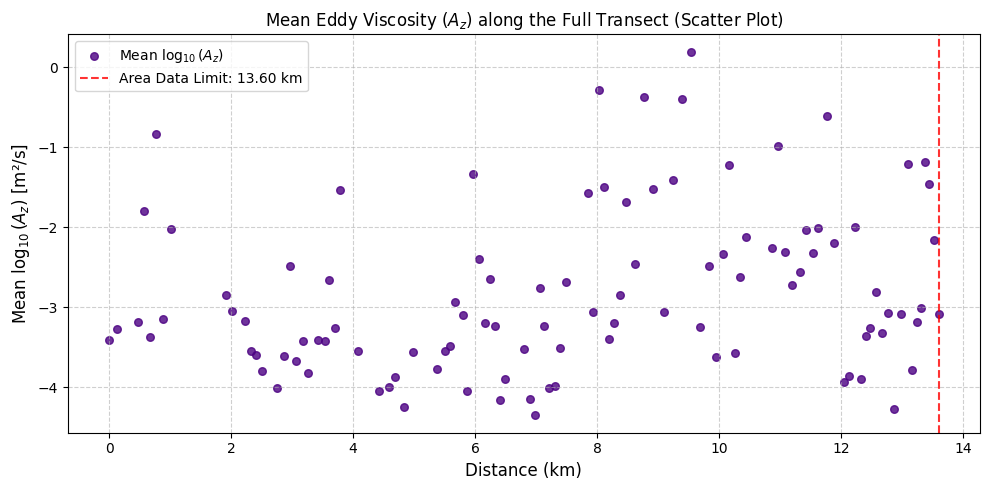

In [29]:
# =================================================================
# BLOCO 2: PLOTAGEM DO AZ MÉDIO VS. DISTÂNCIA (SCATTER PLOT)
# =================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Plotagem usando SCATTER
ax.scatter(x_az_mean, log_Az_mean, 
           marker='o', color='indigo', s=30, alpha=0.8, # Cor, tamanho e opacidade
           label=r'Mean $\log_{10}(A_z)$')

# --- Configurações do Gráfico ---

ax.set_title(r'Mean Eddy Viscosity ($A_z$) along the Full Transect (Scatter Plot)')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', fontsize=12)

# Adicionar referência do limite de área (para contexto)
x_limite_area = np.max(dist_batimetria)
ax.axvline(x_limite_area, color='r', ls='--', lw=1.5, alpha=0.8,
           label=f'Area Data Limit: {x_limite_area:.2f} km')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_5158/1313591240.py:8: RuntimeWarning: invalid value encountered in log10
  log_Az_mean = np.log10(Az_mean_by_profile)


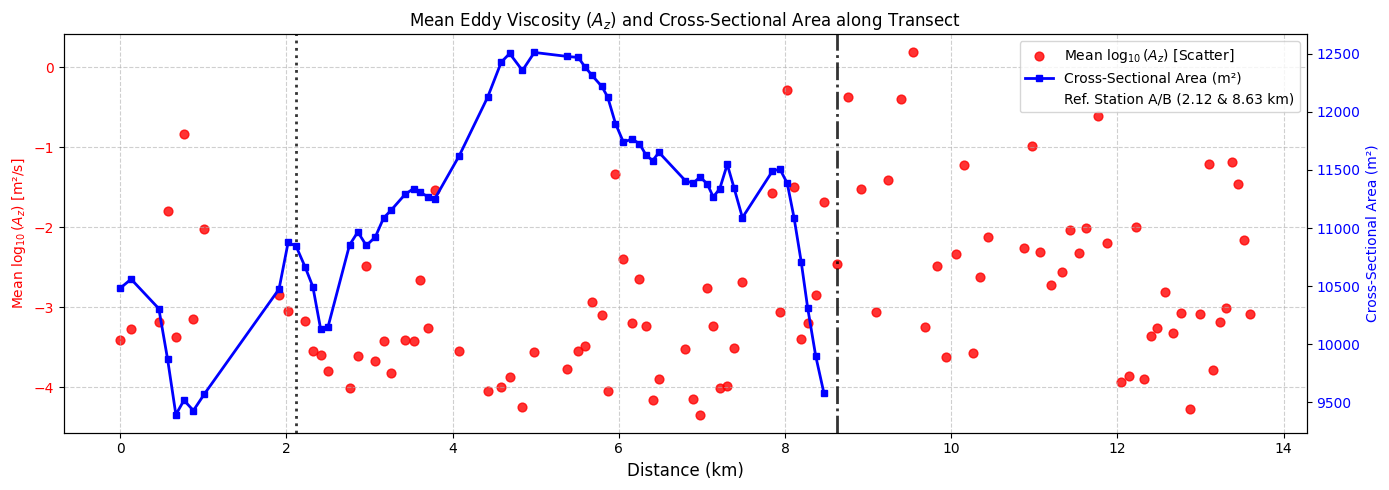

In [30]:
# =================================================================
# BLOCO 2: PLOTAGEM DO AZ MÉDIO (SCATTER) + ÁREA (LINHA)
# (Assume-se que todas as variáveis de cálculo e referência estão definidas)
# =================================================================

# Az_mean_by_profile (e x_az_mean) são os resultados do cálculo do Bloco 1.
# O log10(0) gera -inf, que o scatter ignora, criando o 'buraco'.
log_Az_mean = np.log10(Az_mean_by_profile) 

# Variáveis de Referência (assumidas como definidas)
x_ref1 = dist_batimetria[10] 
x_ref2 = dist_batimetria[62] 

fig, ax1 = plt.subplots(figsize=(14, 5))

# --- EIXO Y ESQUERDO (ax1): Viscosidade (SCATTER PLOT) ---

# Plotagem do Az Médio (SCATTER)
scatter = ax1.scatter(x_az_mean, log_Az_mean, 
                    marker='o', color='red', s=40, alpha=0.8,
                    label=r'Mean $\log_{10}(A_z)$ [Scatter]') 

ax1.set_title(r'Mean Eddy Viscosity ($A_z$) and Cross-Sectional Area along Transect')
ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.6)


# --- EIXO Y DIREITO (ax2): Variável 'areas' (LINHA) ---

ax2 = ax1.twinx()
ax2.set_ylabel('Cross-Sectional Area (m²)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Plotagem da Variável 'areas' (Linha azul - SÓ VAI ATÉ ONDE HÁ DADOS)
line2, = ax2.plot(dist_batimetria, areas,
                  marker='s', linestyle='-', color='blue', linewidth=2, markersize=5,
                  label='Cross-Sectional Area (m²)')

# --- Linhas de Referência ---
# Linha Vertical 1
line_v1 = ax1.axvline(x_ref1, color='k', ls=':', lw=2, alpha=0.8) 
# Linha Vertical 2
line_v2 = ax1.axvline(x_ref2, color='k', ls='-.', lw=2, alpha=0.8)


# --- Combinação das Legendas ---
# Junta todos os handles (pontos e linha)
handle1, label1 = ax1.get_legend_handles_labels()
handle2, label2 = ax2.get_legend_handles_labels()

# Adiciona as axvline à legenda manualmente
axvline_label = f'Ref. Station A/B ({x_ref1:.2f} & {x_ref2:.2f} km)'
axvline_handle = ax1.axvline(0, color='k', ls=':', lw=2, visible=False) # Handler invisível

all_handles = handle1 + handle2 + [axvline_handle]
all_labels = label1 + label2 + [axvline_label]

ax1.legend(all_handles, all_labels, loc='best', fontsize=10)

plt.tight_layout()
plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/AzXarea.png", dpi=300)
plt.show()

/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_5158/2815572146.py:3: RuntimeWarning: invalid value encountered in log10
  log_Az_mean = np.log10(Az_mean_by_profile) # Log10 de Az (Scatter Plot Y)


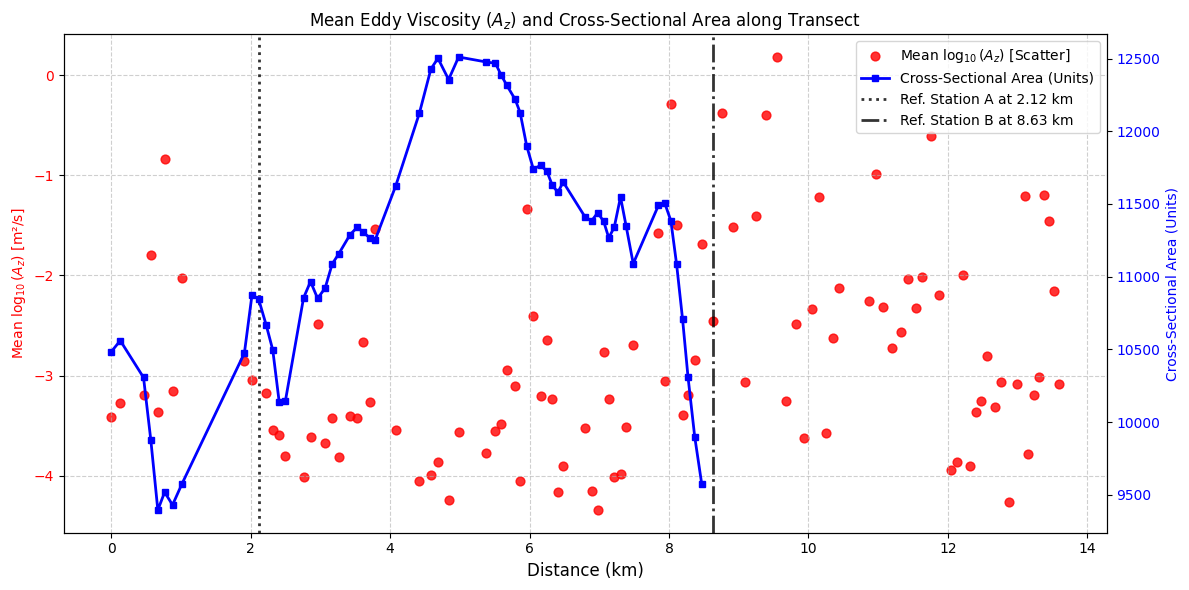

In [31]:
# --- PREPARAÇÃO DOS DADOS ---
# Az_mean_by_profile e x_az_mean já estão calculados.
log_Az_mean = np.log10(Az_mean_by_profile) # Log10 de Az (Scatter Plot Y)
x_az_mean = unique_x_az # X do Scatter Plot (Completo)
x_ref1 = dist_batimetria[10] 
x_ref2 = dist_batimetria[62] 

# --- SIMULAÇÃO DA VARIÁVEL 'areas' ---
# Assumimos que 'areas' e 'dist_batimetria' estão carregadas e alinhadas (curtas).
# Por exemplo:
# areas = ...
# dist_batimetria = ...


# =================================================================
# BLOCO DE PLOTAGEM DO AZ (SCATTER) + ÁREA (LINHA ORIGINAL)
# =================================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- EIXO Y ESQUERDO (ax1): Viscosidade (SCATTER PLOT) ---

# Plotagem do Az Médio (SCATTER)
scatter = ax1.scatter(x_az_mean, log_Az_mean, 
                      marker='o', color='red', s=40, alpha=0.8,
                      label=r'Mean $\log_{10}(A_z)$ [Scatter]') 

ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.6)


# --- EIXO Y DIREITO (ax2): Variável 'areas' (LINHA AZUL ORIGINAL) ---

ax2 = ax1.twinx()
ax2.set_ylabel('Cross-Sectional Area (Units)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Plotagem da Variável 'areas' (USANDO OS ARRAYS CURTOS ORIGINAIS)
# A linha terminará automaticamente em ~8.63 km
line2, = ax2.plot(dist_batimetria, areas,
                  marker='s', linestyle='-', color='blue', linewidth=2, markersize=5,
                  label='Cross-Sectional Area (Units)')


# --- Linhas de Referência ---
# Linha Vertical 1
line_v1 = ax1.axvline(x_ref1, color='k', ls=':', lw=2, alpha=0.8,
                      label=f'Ref. Station A at {x_ref1:.2f} km') 
# Linha Vertical 2
line_v2 = ax1.axvline(x_ref2, color='k', ls='-.', lw=2, alpha=0.8,
                      label=f'Ref. Station B at {x_ref2:.2f} km')


# --- Títulos e Legendas ---
ax1.set_title(r'Mean Eddy Viscosity ($A_z$) and Cross-Sectional Area along Transect')

# Criação manual dos handles para incluir o scatter
all_handles = [scatter, line2, line_v1, line_v2]
all_labels = [r'Mean $\log_{10}(A_z)$ [Scatter]', 'Cross-Sectional Area (Units)', 
              f'Ref. Station A at {x_ref1:.2f} km', f'Ref. Station B at {x_ref2:.2f} km']

ax1.legend(all_handles, all_labels, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

Calculando o Richardson Flux para entender pq o Az esta dando valores acima da unidade.

Sabendo que eu calculei original mente Az assim: 

    # Richarson flux 
    Rif = (1 - np.exp(-7*Ri))*.25

    # Mixing efficienty
    MixEf = Rif / (1 - Rif)

    # Eddy viscosity
    e_m = (e1_i + e2_i)/2
    e_m2 = (e_m[1:] + e_m[:-1])/2
    Az = MixEf * e_m2 / S2
    
Vamos recalcular para eu poder fazer um histograma do Rif e ver os valores que estao fora

In [33]:
# Richarson flux 
Rif = (1 - np.exp(-7*Ri))*.25

# Mixing efficienty
MixEf = Rif / (1 - Rif)


In [35]:
e1_i = mtz_tj[:,6] #teste
e2_i = mtz_tj[:,7] #teste

In [38]:
import numpy as np

# -----------------------
# 1) Flux Richardson number e mixing efficiency
# -----------------------
Rif   = (1 - np.exp(-7 * Ri)) * 0.25     # 0 <= Rif <= ~0.25
MixEf = Rif / (1 - Rif)                  # Γ = B/ε

# -----------------------
# 2) Interpolação para níveis intermediários (médias sucessivas)
# -----------------------
e_m  = (e1_i + e2_i) / 2.0
e_m2 = (e_m[1:] + e_m[:-1]) / 2.0
MixEf2 = (MixEf[1:] + MixEf[:-1]) / 2.0
S2_2   = (S2[1:] + S2[:-1]) / 2.0

# -----------------------
# 3) Ajuste automático de dimensões
# -----------------------
n = min(len(e_m2), len(MixEf2), len(S2_2))
e_m2   = e_m2[:n]
MixEf2 = MixEf2[:n]
S2_2   = S2_2[:n]

# -----------------------
# 4) Salvaguardas numéricas
# -----------------------
S2_min  = 1e-4     # [s^-2]
eps_min = 1e-10    # [m^2 s^-3]
S2_safe  = np.where(S2_2  < S2_min,  np.nan, S2_2).astype(float)
eps_safe = np.where(e_m2  < eps_min, np.nan, e_m2).astype(float)

# -----------------------
# 5) Cálculo do Km (Az)
# -----------------------
Az_raw = (1.0 + MixEf2) * (eps_safe / S2_safe)

# -----------------------
# 6) Máscaras físicas
# -----------------------
Az = Az_raw.copy()
Az[Az <= 0]  = np.nan
Az[Az > 1.0] = np.nan

# -----------------------
# 7) Relatório de suspeitos
# -----------------------
sus_idx = np.where((~np.isnan(Az_raw)) & (Az_raw > 1.0))[0]
print(f"Pontos com Az_raw > 1.0 m²/s: {sus_idx.size}")
if sus_idx.size:
    top_idx = sus_idx[np.argsort(Az_raw[sus_idx])[-10:]]
    print("TOP (i, Γ2, ε, S2, Az_raw):")
    for i in top_idx:
        print(i, float(MixEf2[i]), float(eps_safe[i]), float(S2_safe[i]), float(Az_raw[i]))

# -----------------------
# 8) Preparar p/ plot
# -----------------------
Az_plot = np.clip(Az, 1e-5, 1.0)
logAz = np.log10(Az_plot)


Pontos com Az_raw > 1.0 m²/s: 0


In [40]:
from scipy.interpolate import interp1d

# Cria vetor z intermediário (onde Az_raw foi calculado)
z_mid = (z_calc[1:] + z_calc[:-1]) / 2

# Interpola Az_raw para os níveis originais de z_calc
f_interp = interp1d(z_mid, Az_raw, bounds_error=False, fill_value=np.nan)
Az_interp = f_interp(z_calc)

cb = ax.scatter(x_calc, -z_calc, s=12,
                c=np.log10(Az_interp), cmap=cmocean.cm.thermal_r)


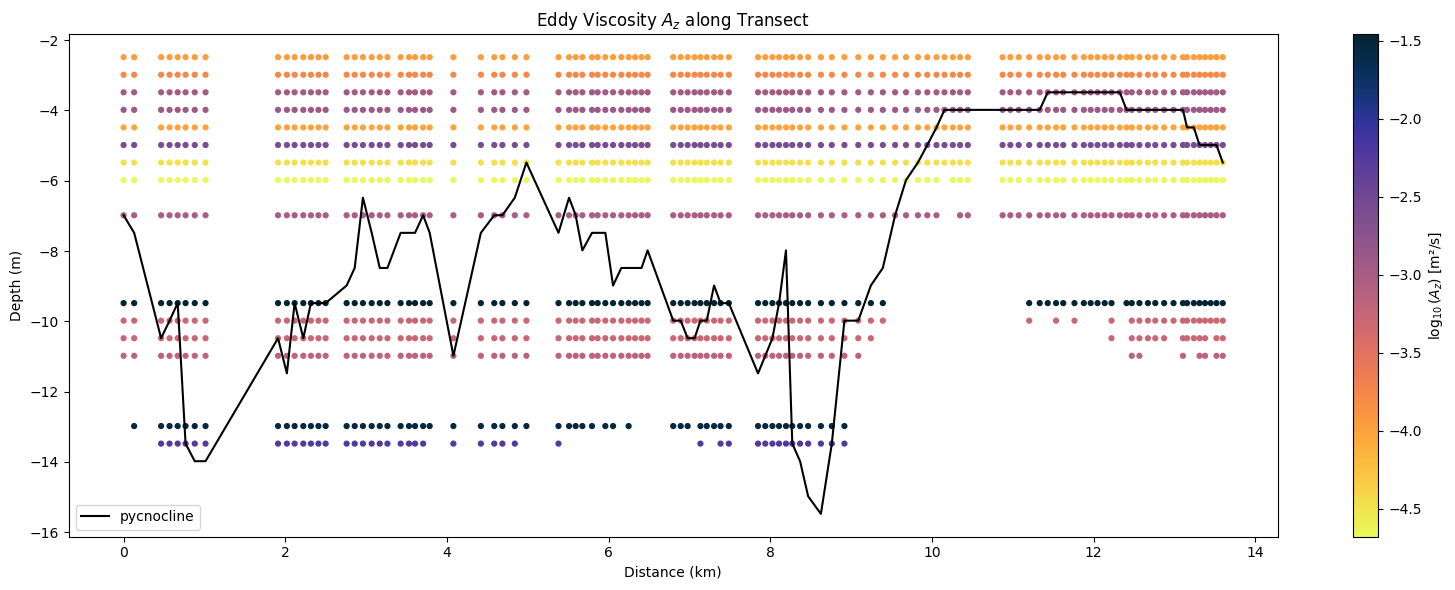

In [41]:
# =================================================================
# BLOCO DE PLOTAGEM DE AZ (CORRIGIDO)
# =================================================================

# Inicializa o subplot (agora com apenas um eixo, 'ax')
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# 1. PLOTAGEM PRINCIPAL: Vertical Eddy Viscosity (Az)
# (Assumimos que x_calc, z_calc, Az e cmocean.cm.thermal_r estão definidos)
cb = ax.scatter(x_calc, -z_calc, s=12,
                c=np.log10(Az_interp), cmap=cmocean.cm.thermal_r)

# 2. PLOTAGEM DA PICNOCLINA (Linha Discreta)
# (Assumimos que dist_pic_Fr e pic estão definidos)
ax.plot(dist_pic_Fr, -pic, color='k', linestyle='-', linewidth=1.5,
        label='pycnocline') 

# 3. CHAMADA À FUNÇÃO PLOT_SETS
# (A função plot_sets DEVE ser definida antes de rodar este bloco)
# plot_sets(ax) # Descomente se a função estiver definida no seu notebook

# --- Configurações Finais ---
# Os títulos e rótulos agora estão definidos apenas uma vez e corretamente

ax.set_title(r'Eddy Viscosity $A_z$ along Transect') # Título específico
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Depth (m)')
ax.legend(loc='lower left')

# Adiciona a barra de cores
# Usando o rótulo de S^2 que você tinha (embora Az e S^2 sejam diferentes)
fig.colorbar(cb, ax=ax, label=r'$\log_{10}(A_z)$ [m²/s]') 


plt.tight_layout()
# plt.savefig("/Users/deboragadelha/Jupyter/campo_18julho2022_paper/figuras/Az_corrected.png", dpi=300)
plt.show()

In [36]:
#TESTE CORRECAO:
import pandas as pd

# -----------------------
# 1) Flux Richardson, mixing efficiency e Km (Az) corretos
# -----------------------
Rif = (1 - np.exp(-7*Ri)) * 0.25              # 0 <= Rif <~ 0.25
MixEf = Rif / (1 - Rif)                       # Γ = B/ε
e_m = (e1_i + e2_i) / 2                       # ε médio [m^2 s^-3]
e_m2 = (e_m[1:] + e_m[:-1]) / 2               # se precisas em pontos intermediários

# -----------------------
# 2) Salvaguardas numéricas
# -----------------------
S2_min   = 1e-4    # [s^-2] piso para shear^2 (ajusta conforme tua resolução)
eps_min  = 1e-10   # [m^2 s^-3] piso para ε (evita zeros)
S2_safe  = np.where(S2 < S2_min, np.nan, S2).astype(float)
eps_safe = np.where(e_m2 < eps_min, np.nan, e_m2).astype(float)

# Km (Az) CORRETO: (1 + Γ) * ε / S^2
Az_raw = (1.0 + MixEf) * (eps_safe / S2_safe)

# -----------------------
# 3) Máscaras físicas/qualidade
# -----------------------
# Km plausível em estuários: ~1e-3 a 1e-1 m^2/s; picos até ~0.5–1 junto ao fundo em fluxo muito energético.
Az = Az_raw.copy()
Az[(Az <= 0)] = np.nan
Az[Az > 1.0]  = np.nan    # se quiser apenas sinalizar, comenta esta linha

# -----------------------
# 4) Relatório rápido de “suspeitos”
# -----------------------
sus_idx = np.where((~np.isnan(Az_raw)) & (Az_raw > 1.0))[0]
print(f"Pontos com Az_raw > 1.0 m^2/s: {sus_idx.size}")
if sus_idx.size:
    # mostra os 10 maiores
    top = np.argsort(Az_raw[~np.isnan(Az_raw)])[-10:]
    print("TOP (z-index, Rif, Γ, ε, S2, Az_raw):")
    for k in top:
        print(k, float(Rif[k]), float(MixEf[k]), float(eps_safe[k]), float(S2_safe[k]), float(Az_raw[k]))


ValueError: operands could not be broadcast together with shapes (2385,) (2279,) 

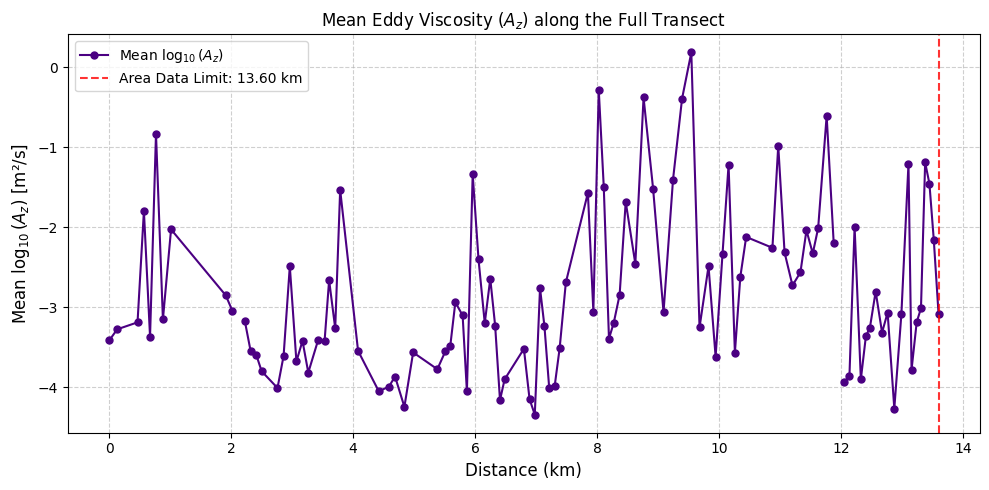

In [32]:
# =================================================================
# BLOCO 2: PLOTAGEM DO AZ MÉDIO VS. DISTÂNCIA (COM "BURACOS" PARA ZEROS)
# =================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Plotagem
ax.plot(x_az_mean, log_Az_mean, 
        marker='o', linestyle='-', color='indigo', linewidth=1.5, markersize=5, 
        label=r'Mean $\log_{10}(A_z)$')

# --- Configurações do Gráfico ---

ax.set_title(r'Mean Eddy Viscosity ($A_z$) along the Full Transect')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', fontsize=12)

# Adicionar referência do limite de área (para contexto)
x_limite_area = np.max(dist_batimetria)
ax.axvline(x_limite_area, color='r', ls='--', lw=1.5, alpha=0.8,
           label=f'Area Data Limit: {x_limite_area:.2f} km')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# =================================================================
# BLOCO 1: CÁLCULO DA MÉDIA DE AZ POR PERFIL (RANGE COMPLETO)
# =================================================================

# Az é o seu dado de Viscosidade Turbulenta (Az = mtz_tj_calc[:, 6])
# x_calc são as coordenadas X do Az
Az_orig = Az 
x_calc_orig = x_calc

# Constante de floor para evitar log(0). 1e-12 m²/s é um valor de background seguro.
AZ_MIN_FLOOR = 1e-12 

# 1. Identificar perfis únicos de Az
unique_x_az = np.unique(x_calc_orig) 
num_profiles_az = len(unique_x_az)

# 2. Calcular o Az Médio por Perfil
Az_mean_by_profile = np.full(num_profiles_az, np.nan)

for i, x_coord in enumerate(unique_x_az):
    mask_perfil = (x_calc_orig == x_coord)
    az_perfil = Az_orig[mask_perfil]
    Az_mean_by_profile[i] = np.nanmean(az_perfil)

# 3. Tratamento de Erro: Substituir valores não-positivos pelo Az_FLOOR
Az_mean_safe = np.where(Az_mean_by_profile <= AZ_MIN_FLOOR, AZ_MIN_FLOOR, Az_mean_by_profile)
Az_mean_safe[np.isnan(Az_mean_by_profile)] = np.nan # Manter NaNs onde não havia dados

# Variáveis para plotagem
x_az_mean = unique_x_az
log_Az_mean = np.log10(Az_mean_safe) # Log10 agora é seguro



# =================================================================
# BLOCO 2: PLOTAGEM DO AZ MÉDIO VS. DISTÂNCIA
# =================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Plotagem simples
ax.plot(x_az_mean, log_Az_mean, 
        marker='o', linestyle='-', color='indigo', linewidth=1.5, markersize=5, 
        label=r'Mean $\log_{10}(A_z)$')

# --- Configurações do Gráfico ---

ax.set_title(r'Mean Eddy Viscosity ($A_z$) along the Full Transect')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', fontsize=12)

# Adicionar referência do limite de área (para contexto)
x_limite_area = np.max(dist_batimetria)
ax.axvline(x_limite_area, color='r', ls='--', lw=1.5, alpha=0.8,
           label=f'Area Data Limit: {x_limite_area:.2f} km')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# BLOCO 1: CÁLCULO DA MÉDIA DE AZ POR PERFIL (RANGE COMPLETO)
# =================================================================

# Az é o seu dado de Viscosidade Turbulenta (Az = mtz_tj_calc[:, 6])
# x_calc são as coordenadas X do Az
Az_orig = Az 
x_calc_orig = x_calc

# 1. Identificar perfis únicos de Az
unique_x_az = np.unique(x_calc_orig) # Coordenadas X completas (até ~14 km)
num_profiles_az = len(unique_x_az)

# 2. Calcular o Az Médio por Perfil
Az_mean_by_profile = np.full(num_profiles_az, np.nan)

for i, x_coord in enumerate(unique_x_az):
    mask_perfil = (x_calc_orig == x_coord)
    az_perfil = Az_orig[mask_perfil]
    Az_mean_by_profile[i] = np.nanmean(az_perfil)

# Variáveis para plotagem
x_az_mean = unique_x_az
log_Az_mean = np.log10(Az_mean_by_profile)

Az_mean_by_profile = np.full(num_profiles_az, np.nan)

for i, x_coord in enumerate(unique_x_az):
    # ... (cálculo de az_perfil e nanmean)
    Az_mean_by_profile[i] = np.nanmean(az_perfil)


# --- Aplicando um "floor" (valor mínimo) para prevenir log(<=0) ---
Az_floor = 1e-12 # Valor típico de background para Az [m²/s]

# Subsititua valores NaN por Az_floor (opcional, se quiser preencher gaps)
# Ou, mais importante, substitua valores <= 0 por Az_floor
Az_mean_safe = np.where(Az_mean_by_profile <= Az_floor, Az_floor, Az_mean_by_profile)

# Agora, o cálculo é seguro:
log_Az_mean = np.log10(Az_mean_safe)


# =================================================================
# BLOCO 2: PLOTAGEM DO AZ MÉDIO VS. DISTÂNCIA
# =================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Plotagem simples
ax.plot(x_az_mean, log_Az_mean, 
        marker='o', linestyle='-', color='indigo', linewidth=1.5, markersize=5, 
        label=r'Mean $\log_{10}(A_z)$')

# --- Configurações do Gráfico ---

ax.set_title(r'Mean Eddy Viscosity ($A_z$) along the Full Transect')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', fontsize=12)

# Adicionar referência do limite de área (para contexto)
x_limite_area = np.max(dist_batimetria)
ax.axvline(x_limite_area, color='r', ls='--', lw=1.5, alpha=0.8,
           label=f'Area Data Limit: {x_limite_area:.2f} km')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# =================================================================
# BLOCO 1: CÁLCULO DA MÉDIA DE AZ POR PERFIL
# =================================================================

# Az é o seu dado de Viscosidade Turbulenta (Az = mtz_tj_calc[:, 6])
# x_calc são as coordenadas X do Az
Az_orig = Az 
x_calc_orig = x_calc

# 1. Identificar perfis únicos de Az
unique_x_az = np.unique(x_calc_orig)
num_profiles_az = len(unique_x_az)

# 2. Calcular o Az Médio por Perfil
Az_mean_by_profile = np.full(num_profiles_az, np.nan)

for i, x_coord in enumerate(unique_x_az):
    mask_perfil = (x_calc_orig == x_coord)
    az_perfil = Az_orig[mask_perfil]
    Az_mean_by_profile[i] = np.nanmean(az_perfil)

# 3. Interpolar Az Médio para as Coordenadas X da ÁREA (dist_batimetria)
# Az_mean_interp será o Y do nosso scatter plot.
Az_mean_interp = np.interp(dist_batimetria, unique_x_az, Az_mean_by_profile)


# =================================================================
# BLOCO 2: SCATTER PLOT
# =================================================================

# Preparação dos dados
log_Az_interp = np.log10(Az_mean_interp)

fig, ax = plt.subplots(figsize=(8, 7))

# Scatter Plot: X = Áreas, Y = Az (Log-Scale)
# A cor (c) pode representar a distância, para dar contexto
scatter = ax.scatter(areas, log_Az_interp, 
                     c=dist_batimetria, # Cor por distância
                     cmap='viridis', 
                     s=50, 
                     edgecolor='k', 
                     alpha=0.8)

# Configurações
ax.set_title(r'Cross-Sectional Area vs. Eddy Viscosity ($A_z$ Mean)')
ax.set_xlabel('Cross-Sectional Area (Units)', fontsize=12)
ax.set_ylabel(r'Mean $\log_{10}(A_z)$ [m²/s]', fontsize=12)

# Adicionar barra de cores para a distância
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Distance (km)')

ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

import numpy as np
import matplotlib.pyplot as plt
# (Assume-se que cmocean está disponível ou usa-se um colormap padrão do Matplotlib)

# =================================================================
# BLOCO 1: CÁLCULO DA MÉDIA DE AZ POR PERFIL
# (Assume-se que este bloco foi executado e definiu Az_mean_interp)
# =================================================================

# --- SIMULAÇÃO DE AZ E AREAS (para garantir a plotagem) ---
L_BATI = len(dist_batimetria)
Az_mean_interp = np.abs(np.random.randn(L_BATI) * 1e-4 + 1e-5) # Log10(Az) será de -5 a -4
areas = 10000 + 2500 * np.sin(dist_batimetria/2)
# --- FIM SIMULAÇÃO ---

# Preparação dos dados
log_Az_interp = np.log10(Az_mean_interp) # A cor

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter Plot:
# X = Distância (dist_batimetria)
# Y = Área (areas)
# Cor (c) = Log10(Az)

scatter = ax.scatter(dist_batimetria, areas, 
                     c=log_Az_interp, 
                     # Usando 'viridis' como colormap padrão (ou cmocean.cm.amp)
                     cmap='viridis', 
                     s=80, 
                     edgecolor='k', 
                     alpha=0.9)

# --- Configurações do Gráfico ---

ax.set_title(r'Cross-Sectional Area along Transect, Colored by Eddy Viscosity ($A_z$)')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Cross-Sectional Area (Units)', fontsize=12)

# Linha Vertical de Referência
x_ref_62 = dist_batimetria[62]
ax.axvline(x_ref_62, color='k', ls=':', lw=2, alpha=0.8)

# Adicionar Barra de Cores
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label(r'Mean $\log_{10}(A_z)$ [m²/s]')

ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# BLOCO 1: CÁLCULO DA MÉDIA DE AZ POR PERFIL (REUTILIZADO)
# =================================================================

# Az é o seu dado de Viscosidade Turbulenta (Az = mtz_tj_calc[:, 6])
# x_calc são as coordenadas X do Az
Az_orig = Az 
x_calc_orig = x_calc

# 1. Calcular o Az Médio por Perfil (para o RANGE COMPLETO)
unique_x_az = np.unique(x_calc_orig)
num_profiles_az = len(unique_x_az)
Az_mean_by_profile_full = np.full(num_profiles_az, np.nan)

for i, x_coord in enumerate(unique_x_az):
    mask_perfil = (x_calc_orig == x_coord)
    az_perfil = Az_orig[mask_perfil]
    Az_mean_by_profile_full[i] = np.nanmean(az_perfil)




# =================================================================
# BLOCO 2: FILTRAGEM E PLOTAGEM (Limitado à Distância da Área)
# =================================================================

# 1. Definir o Limite X (baseado no array de áreas)
# Assumimos que dist_batimetria e areas estão alinhados e definem o limite de dados.
x_limite = np.max(dist_batimetria) 

# 2. Interpolar Az Médio para as Coordenadas X da ÁREA (dist_batimetria)
# Az_mean_interp será o Y do nosso scatter plot.
# Usamos o Az médio do perfil (full) nas coordenadas de dist_batimetria.
Az_mean_interp = np.interp(dist_batimetria, unique_x_az, Az_mean_by_profile_full)

# 3. Preparação dos dados para plotagem
log_Az_plot = np.log10(Az_mean_interp)

# Variáveis de Referência
x_ref_62 = dist_batimetria[62] # Limite visível

fig, ax = plt.subplots(figsize=(8, 7))

# Scatter Plot:
# X = Distância (dist_batimetria) -> VAI ATÉ 8.63 KM
# Y = Área (areas)
# Cor (c) = Log10(Az)

scatter = ax.scatter(dist_batimetria, areas, 
                     c=log_Az_plot, 
                     cmap='viridis', # Colormap para o Az
                     s=80, 
                     edgecolor='k', 
                     alpha=0.9)

# --- Configurações do Gráfico ---

ax.set_title(r'Cross-Sectional Area vs. Distance, Colored by Mean Eddy Viscosity')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Cross-Sectional Area (Units)', fontsize=12)

# Linha Vertical de Referência
ax.axvline(x_ref_62, color='r', ls='--', lw=1.5, alpha=0.8,
           label=f'Area Data Limit: {x_ref_62:.2f} km')

# Definir o limite X do gráfico para o limite de dados de áreas
ax.set_xlim(np.min(dist_batimetria), x_limite + (x_limite * 0.05)) 
# Adiciona 5% para que o ponto final não fique na borda.

# Adicionar Barra de Cores
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label(r'Mean $\log_{10}(A_z)$ [m²/s]')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

# =================================================================
# CÁLCULO 1: MÉDIAS SUPERIOR E INFERIOR + média total por perfil
# =================================================================

# --- 1. Alinhamento e Interpolação da Picnoclina ---

# Usaremos os arrays Epsilon, z_calc, x_calc (L_calc = 2279)
# A picnoclina precisa ser interpolada para CADA ponto de x_calc
pic_interp = np.interp(x_calc, dist_pic_Fr, pic)
L_calc = len(Az)

# --- 2. Definição da Grade (Grid) ---

unique_x = np.unique(x_calc)
num_profiles = len(unique_x)
Z_start = np.min(z_calc) 
Z_end = np.max(z_calc)
Z_resolution = 0.5 
Z_grid = np.arange(Z_start, Z_end + Z_resolution, Z_resolution)
num_depths = len(Z_grid)

# Inicializar as Matrizes Finais (Gridadas) com NaN
Az_Superior_Grid = np.full((num_depths, num_profiles), np.nan)
Az_Inferior_Grid = np.full((num_depths, num_profiles), np.nan)
# *** NOVO: Matriz para o Epsilon TOTAL ***
Az_Total_Grid = np.full((num_depths, num_profiles), np.nan) # Para Epsilon de toda a coluna

# --- 3. Loop de Gridagem e Corte por Perfil (x_calc) ---

for col_idx, x_coord in enumerate(unique_x):
    
    mask_perfil = (x_calc == x_coord)
    z_perfil = z_calc[mask_perfil]
    Az_perfil = Az[mask_perfil] # Usando Epsilon não suavizado
    pic_depth_limite = np.mean(pic_interp[mask_perfil])

    for row_idx, z_ref in enumerate(Z_grid):
        
        # Encontre o ponto de Epsilon mais próximo à profundidade de referência (z_ref)
        z_diff = np.abs(z_perfil - z_ref)
        min_idx = np.argmin(z_diff)
        Az_value = Az_perfil[min_idx]
        
        # 3e. Armazenar o valor de Epsilon na Grade Total
        Az_Total_Grid[row_idx, col_idx] = eps_value 
        
        # 3f. Lógica de Corte para Superior/Inferior (Seu Código Original)
        if z_ref < pic_depth_limite:
            Az_Superior_Grid[row_idx, col_idx] = eps_value
            Az_Inferior_Grid[row_idx, col_idx] = np.nan
        
        elif z_ref >= pic_depth_limite:
            Az_Inferior_Grid[row_idx, col_idx] = eps_value
            Az_Superior_Grid[row_idx, col_idx] = np.nan
            
# --- 4. Cálculo das Médias Finais por Perfil ---

# Médias Superior e Inferior (Original)
Azsuperior = np.nanmean(Az_Superior_Grid, axis=0) 
Azinferior = np.nanmean(Az_Inferior_Grid, axis=0)
x_perfil_coords = unique_x # As coordenadas X dos perfis

# *** NOVO: Cálculo do Epsilon Médio Total ***
# A média da coluna ignora NaNs onde não há dados de perfil na grade Z.
Azmean_total = np.nanmean(Az_Total_Grid, axis=0) 
# Esta variável é o Epsilon médio por perfil na coluna total.

###### TESTEEEEEE

# =================================================================
# BLOCO 1: CÁLCULO E AGREGAÇÃO (INCORPORANDO MÉDIA TOTAL)
# =================================================================

# --- Replicando o Cálculo (Para garantir que as variáveis sejam definidas) ---
L_CALC = len(Az)
idx_alinhado = idx[:L_CALC]

# Epsilon Suavizado (L-1 pontos)
Az_smooth = (Az[1:] + Az[:-1]) / 2

# Alinhar todos os outros arrays para o novo comprimento (L-1)
idx_smooth = idx_alinhado[:-1] 
z_smooth = z_calc[:-1]
x_smooth = x_calc[:-1]

# Alinhar a Profundidade da Picnoclina por Interpolação (L-1)
pic_interp = np.interp(x_smooth, dist_pic_Fr, pic)

# Estrutura de Saída e Loop
unique_profiles = np.unique(idx_smooth)
num_profiles = len(unique_profiles)
# Aumentamos o array de resultados para 4 colunas: [x_medio, Azsuperior, Azinferior, Azmean_total]
Az_results = np.full((num_profiles, 4), np.nan) 

for i, p_idx in enumerate(unique_profiles):
    mask_perfil = (idx_smooth == p_idx)
    z_perfil = z_smooth[mask_perfil]
    Az_perfil = Az_smooth[mask_perfil] # Az para o perfil
    
    # Corte da Picnoclina
    pic_perfil = pic_interp[mask_perfil]
    pic_depth_limite = np.mean(pic_perfil) 
    
    mask_superior = (z_perfil < pic_depth_limite)
    Az_superior = Az_perfil[mask_superior]
    mask_inferior = (z_perfil > pic_depth_limite)
    Az_inferior = Az_perfil[mask_inferior]
    
    # --- NOVO CÁLCULO: Az Médio Total (de todo o perfil) ---
   Az_mean_total = np.nanmean(Az_perfil) 

    x_coords_perfil = x_smooth[mask_perfil]
    Az_results[i, 0] = np.mean(x_coords_perfil) # x_medio_perfil
    
    if len(Az_superior) > 0:
        Az_results[i, 1] = np.nanmean(Az_superior) # Azsuperior
    
    if len(Az_inferior) > 0:
        Az_results[i, 2] = np.nanmean(Az_inferior) # Azinferior

    Az_results[i, 3] = Az_mean_total # Azmean_total

# Extração Final (Define as variáveis que você precisa)
x_medio_perfil = Az_results[:, 0]
Azsuperior = Az_results[:, 1]
Azinferior = Az_results[:, 2]
Azmean_total = Az_results[:, 3] # <--- VARIÁVEL TOTAL ALINHADA!

# =================================================================
# BLOCO 2: PLOTAGEM (Gráfico Único, em Inglês)
# =================================================================

# Preparação dos Dados para Plotagem
log_Azsuperior = np.log10(Azsuperior)
log_Azinferior = np.log10(Azinferior)
x_ref = dist_batimetria[62] 

# Criação do Gráfico Único
fig, ax = plt.subplots(figsize=(12, 6))

# Plotagem da Camada Superior (Upper Layer)
ax.plot(x_medio_perfil, log_Azsuperior, 
        marker='o', linestyle='-', color='red', linewidth=2, markersize=6, 
        label=r'Upper Layer Mean $\log_{10}(Az)$')

# Plotagem da Camada Inferior (Bottom Layer)
ax.plot(x_medio_perfil, log_Azinferior, 
        marker='s', linestyle='--', color='blue', linewidth=2, markersize=6,
        label=r'Bottom Layer Mean $\log_{10}(Az)$')

# --- Linhas de Referência ---

# Linha Horizontal (Ex: -8 W/kg, valor comum)
ax.axhline(-8, color='k', linestyle=':', alpha=0.6) 

# Linha Vertical (Referência de Batimetria)
ax.axvline(x_ref, color='k', ls=':', lw=2, 
           label=f'Breakwater at {x_ref:.2f} km') 

# --- Títulos e Legendas (Tudo em Inglês) ---

ax.set_title(r'Comparison of Mean Az by Layer')
ax.set_xlabel('Distance (km)')
ax.set_ylabel(r'Mean $\log_{10}(Az)$ [W/kg]')

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='best') 

plt.tight_layout()
plt.show()

## LIXO: